In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

## Load data

In [2]:
df = pd.read_csv('/Users/jamesemcnally/Dropbox/DSBC Student Risk Factors Datasets/combined_presentations_data_w3.csv')

In [3]:
pd.set_option('display.max_columns', 60)

df.head(5)

,id_student,code_module,code_presentation,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,date_registration,date_unregistration,module_presentation_length,total_vle_pre_w3,content_focus_pre_w3,collaborative_focus_pre_w3,vle_richness_pre_w3,diversity_shannon_pre_w3,active_days_per_week_pre_w3,std_regularity_pre_w3,date,id_assessment,is_banked,score,assessment_type,first_due_date,weight,week,submitted_first_assessment,relative_submission_date,submission_type
0,6516,AAA,2014J,M,Scotland,HE Qualification,80-90%,55<=,0,60,N,Pass,-52.0,NaN,269,606.0,0.739274,0.260726,6,2.094273,1.812654,1.358621,17.0,1758.0,0.0,60.0,TMA,19.0,10.0,3.0,1,2.0,Late
1,11391,AAA,2013J,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,-159.0,NaN,268,401.0,0.862843,0.137157,6,1.479023,1.414214,2.627691,18.0,1752.0,0.0,78.0,TMA,19.0,10.0,3.0,1,1.0,Late
2,23698,CCC,2014J,F,East Anglian Region,A Level or Equivalent,50-60%,0-35,0,120,N,Pass,-110.0,NaN,269,352.0,0.241477,0.068182,7,1.503976,2.160247,0.770281,21.0,24295.0,0.0,78.0,CMA,18.0,2.0,4.0,1,-3.0,Early
3,23798,BBB,2013J,M,Wales,A Level or Equivalent,50-60%,0-35,0,60,N,Distinction,-27.0,NaN,268,115.0,0.495652,0.504348,7,2.031535,1.414214,3.236694,18.0,14996.0,0.0,90.0,TMA,19.0,5.0,3.0,1,1.0,Late
4,24734,AAA,2014J,F,South Region,Lower Than A Level,60-70%,0-35,0,60,N,Pass,-18.0,NaN,269,87.0,0.781609,0.218391,5,1.777750,0.894427,5.618846,23.0,1758.0,0.0,41.0,TMA,19.0,10.0,4.0,1,-4.0,Early


In [4]:
df.columns

Index(['id_student', 'code_module', 'code_presentation', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result', 'date_registration',
       'date_unregistration', 'module_presentation_length', 'total_vle_pre_w3',
       'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 'date',
       'id_assessment', 'is_banked', 'score', 'assessment_type',
       'first_due_date', 'weight', 'week', 'submitted_first_assessment',
       'relative_submission_date', 'submission_type'],
      dtype='object')

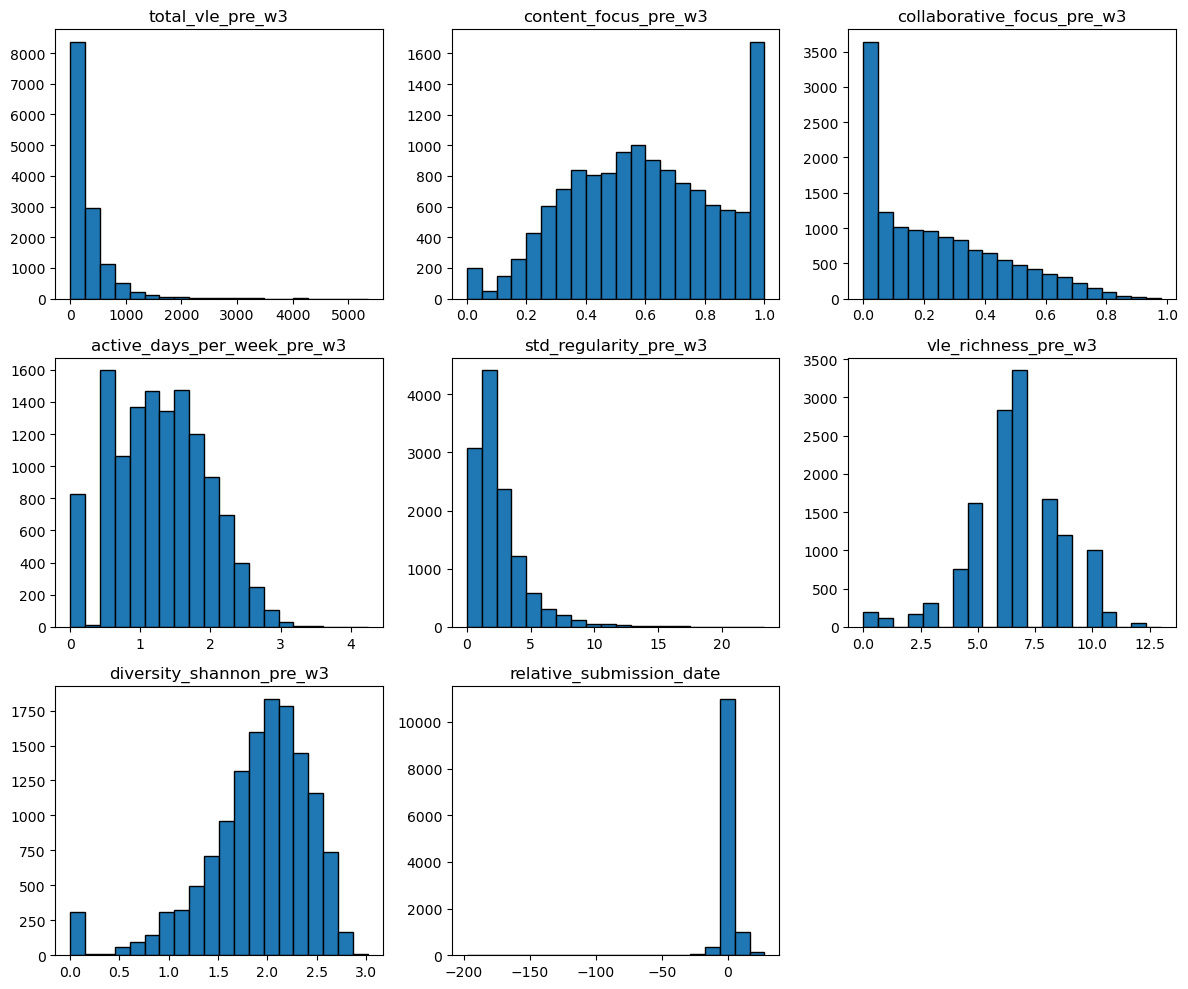

In [5]:
columns_to_display = ['total_vle_pre_w3', 'content_focus_pre_w3',
       'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
       'std_regularity_pre_w3', 'vle_richness_pre_w3',
       'diversity_shannon_pre_w3', 'relative_submission_date',
       'submission_type']

# Select only the specified columns and create histograms
df[columns_to_display].hist(bins=20, figsize=(12, 10), edgecolor='black', grid=False)
plt.tight_layout()
plt.show()

In [6]:
# Set random seed for reproducibility
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random seed set to {SEED}")

Random seed set to 42


Distribution of final_result:

Absolute counts:
final_result
Pass           6240
Fail           3018
Withdrawn      2676
Distinction    1537
Name: count, dtype: int64

Percentage distribution:
final_result
Pass           46.321728
Fail           22.403682
Withdrawn      19.864895
Distinction    11.409695
Name: proportion, dtype: float64


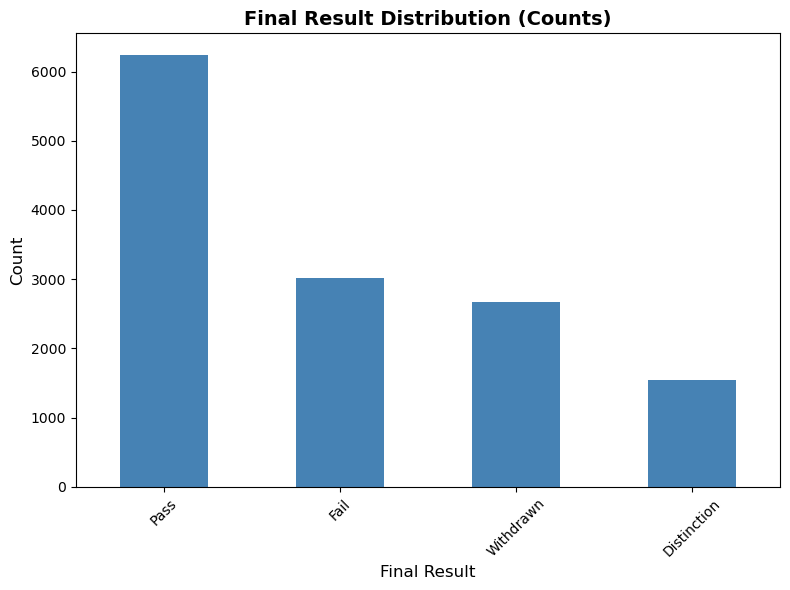


Total students: 13471
Unique categories: 4


In [7]:
# Examine the distribution of final_result

print("Distribution of final_result:")
print("=" * 50)

# Count by category
print("\nAbsolute counts:")
print(df['final_result'].value_counts())

# Percentage distribution
print("\nPercentage distribution:")
print(df['final_result'].value_counts(normalize=True) * 100)

# Visualization - counts only
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

df['final_result'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Final Result Distribution (Counts)', fontsize=14, fontweight='bold')
plt.xlabel('Final Result', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("\n" + "=" * 50)
print(f"Total students: {len(df)}")
print(f"Unique categories: {df['final_result'].nunique()}")

## Data preprocessing

In [8]:
# Check sums of NA in each columns 
print(df.isna().sum())

columns_with_NA = df.columns[df.isna().any()].tolist()

id_student                         0
code_module                        0
code_presentation                  0
gender                             0
region                             0
highest_education                  0
imd_band                         503
age_band                           0
num_of_prev_attempts               0
studied_credits                    0
disability                         0
final_result                       0
date_registration                  0
date_unregistration            10833
module_presentation_length         0
total_vle_pre_w3                   0
content_focus_pre_w3               0
collaborative_focus_pre_w3         0
vle_richness_pre_w3                0
diversity_shannon_pre_w3           0
active_days_per_week_pre_w3      717
std_regularity_pre_w3            981
date                             917
id_assessment                      0
is_banked                        917
score                            933
assessment_type                    0
f

In [9]:
columns_with_NA

['imd_band',
 'date_unregistration',
 'active_days_per_week_pre_w3',
 'std_regularity_pre_w3',
 'date',
 'is_banked',
 'score',
 'week',
 'relative_submission_date']

In [10]:
from sklearn.model_selection import train_test_split

# Create binary target variable
# 1 = Fail/Withdrawn 
# 0 = Pass/Distinction 
df['target'] = df['final_result'].isin(['Fail', 'Withdrawn']).astype(int)

# Create a copy of the original df with the features we need
feature_columns = [
    'code_module', 
    'content_focus_pre_w3',
    'collaborative_focus_pre_w3', 
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3', 
    'vle_richness_pre_w3',
    'diversity_shannon_pre_w3', 
    #'relative_submission_date', # - ABF commented out for now because it can't be filled with 0 and would cause student who never submitted to get dropped
    'submission_type',
    'total_vle_pre_w3'
    #'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'disability'
]

# Create working dataframe with features + target
df_model = df[feature_columns + ['target']].copy()

# Assign zeros to all interaction features that are null *except* submission_type
columns_to_fill_zeros = [ # Based on the NA check above, these two are the only columns that have NA - ABF
    #'content_focus_pre_w3',
    #'collaborative_focus_pre_w3',
    'active_days_per_week_pre_w3',
    'std_regularity_pre_w3',
    #'vle_richness_pre_w3',
    #'diversity_shannon_pre_w3',
    #'total_vle_pre_w3',
    #'relative_submission_date' # we shouldn't fill this with 0 (that would mean the student turned the assignment in on-time) - ABF
]
df_model[columns_to_fill_zeros] = df_model[columns_to_fill_zeros].fillna(0)
# df_model['submission_type'] = df_model['submission_type'].fillna('Late') - ABF commented out
df_model_clean = df_model.dropna() 
# this will drop rows that have NA in relative_submission_date - I think we can just remove this as a feature for now since it's causing issues - ABF

## Initial train-test split

In [11]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']


# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

In [12]:
# Verify split distributions

print("\nTarget distribution:")
print("-" * 60)
print(f"Original (1 = At-Risk): {y.value_counts(normalize = True).sort_index().values}")
print(f"Train (1 = At-Risk):    {y_train.value_counts(normalize = True).sort_index().values}")
print(f"Test (1 = At-Risk):     {y_test.value_counts(normalize = True).sort_index().values}")

print("\nModule distribution:")
print("-" * 60)
train_indices = X_train.index
test_indices = X_test.index

print(f"Original:   {X["code_module"].value_counts(normalize = True).sort_index().values}")
print(f"Train:      {X["code_module"].loc[train_indices].value_counts(normalize = True).sort_index().values}")
print(f"Test:       {X["code_module"].loc[test_indices].value_counts(normalize = True).sort_index().values}")



Target distribution:
------------------------------------------------------------
Original (1 = At-Risk): [0.57731423 0.42268577]
Train (1 = At-Risk):    [0.57720861 0.42279139]
Test (1 = At-Risk):     [0.57773655 0.42226345]

Module distribution:
------------------------------------------------------------
Original:   [0.05062727 0.39588746 0.24927622 0.08863485 0.2155742 ]
Train:      [0.05057535 0.39587973 0.24935041 0.08862287 0.21557164]
Test:       [0.05083488 0.39591837 0.24897959 0.08868275 0.21558442]


In [13]:
X_train.columns

Index(['code_module', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'submission_type',
       'total_vle_pre_w3'],
      dtype='object')

## Define models

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost.sklearn import XGBClassifier

from sklearn.dummy import DummyClassifier

from sklearn.preprocessing import StandardScaler, RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [15]:
# Define preprocessors
scale_cols = ['content_focus_pre_w3', 'collaborative_focus_pre_w3', 'active_days_per_week_pre_w3',
              'std_regularity_pre_w3', 'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 
              'total_vle_pre_w3']
cat_cols = ['code_module', 'submission_type']

cat_processor = ColumnTransformer(
    transformers = [('cat_encode', OneHotEncoder(), cat_cols)],
    remainder = 'passthrough'
)

catscale_processor = ColumnTransformer(
    transformers = [('scale', RobustScaler(), scale_cols),
                   ('cat_encode', OneHotEncoder(), cat_cols)],
    remainder = 'passthrough'
)

In [16]:
# Define model pipelines
models = {
    'Baseline (Stratified)': DummyClassifier(strategy='stratified', random_state=SEED),
    'Logistic Regression': Pipeline([('preprocess', catscale_processor), 
                                     ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                                                     penalty='elasticnet', l1_ratio=0.5, C=0.1,
                                                                     class_weight='balanced'))]),
    'Random Forest': Pipeline([('preprocess', cat_processor), 
                               ('classify', RandomForestClassifier(random_state=SEED, n_estimators=100, max_depth=6,
                                                                   min_samples_split=50, min_samples_leaf=25,
                                                                   max_features='sqrt', max_samples=0.7,
                                                                   class_weight='balanced'))]),
    'XGBoost': Pipeline([('preprocess', cat_processor),
                         ('classify', XGBClassifier(random_state=SEED))])
}

In [17]:
X_train.columns

Index(['code_module', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
       'active_days_per_week_pre_w3', 'std_regularity_pre_w3',
       'vle_richness_pre_w3', 'diversity_shannon_pre_w3', 'submission_type',
       'total_vle_pre_w3'],
      dtype='object')

## Train and compare models

In [18]:
from sklearn.base import clone
from sklearn.metrics import confusion_matrix, roc_auc_score, precision_score, recall_score, f1_score, accuracy_score
from sklearn.model_selection import cross_validate

Note we have marked "Pass / Distinction" as 0 and "Fail / Withdrawn [after week 4]" as 1. With this encoding, "positive" classifications are "Fail / Withdrawn", and "negative" classifications are "Pass / Distinction" (in short: we are classifying whether a student is "at risk" or not.) Hence:
- the recall (also known as sensitivity) gives the proportion of at-risk students that the model correctly identifies;
- the specificty gives the proportion of not-at-risk students that the model correctly identifies;
- the precision gives the proportion of students flagged as at-risk by the model that actually fail / withdraw.
Maximizing recall corresponds to identifying as many at-risk students as possible; increasing precision corresponds to reducing the number of false positives. 

### Using `cross_validate`

In order to use `cross_validate` we stratify only by outcome, not by module.

In [19]:
# Train and evaluate with cross-validation
results = {}

for model in models:
    results[model] = cross_validate(models[model], X_train, y_train,
                                     scoring = ("roc_auc", "recall", "precision", "f1"), cv=5)

# Clean up results dictionary
summary_results = {}
for model in models:
    summary_results[model] = {'test_roc_auc' : np.mean(results[model]['test_roc_auc']),
                              'test_recall' : np.mean(results[model]['test_recall']),
                              'test_precision' : np.mean(results[model]['test_precision']),
                              'test_f1' : np.mean(results[model]['test_f1'])}
 

In [20]:
# Summarize the results in table form [JEM modified 10/21]

summary_df = pd.DataFrame(summary_results).T
print(summary_df.to_string())

                       test_roc_auc  test_recall  test_precision   test_f1
Baseline (Stratified)      0.503068     0.434593        0.426265  0.430388
Logistic Regression        0.709716     0.615017        0.588563  0.601382
Random Forest              0.708277     0.586482        0.600671  0.593203
XGBoost                    0.670546     0.477394        0.590250  0.527774


### Manually using `StratifiedKFold`

This takes more code, but we can now stratify over module as well as module.
Note we first need to redo the train-test split so that we can further do stratified splits on the training test during cross-validation.

In [21]:
# Separate features and target
X = df_model_clean.drop('target', axis = 1)
y = df_model_clean['target']

# Create combined stratification column (target + code_module)
stratify_column = y.astype(str) + '_' + X['code_module']

## Keep extra copy of column in X_train for further use in cross-validation splits
X["stratify"] = stratify_column

# Train/test split with stratification on target variable + module
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    stratify = stratify_column,
    random_state = SEED
)

X_test.drop(["stratify"], axis=1, inplace=True)

# Set X_train, y_train up for stratified splits during cross-validation
y_train = X_train["stratify"]
X_train.drop(["stratify"], axis=1, inplace=True)

# def extract_target(stratification_code):
#     return (int(stratification_code[0]))

In [22]:
from sklearn.model_selection import StratifiedKFold

# Train and evaluate with cross-validation
results = []
skf = StratifiedKFold(n_splits=5)

for model in models:
    auc, recall, precision, f1, overfit_gap = [], [], [], [], []
    for i, (train_index, test_index) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_index]
        y_tt = y_train.iloc[train_index].apply(lambda x: int(x[0]))

        X_ho = X_train.iloc[test_index]
        y_ho = y_train.iloc[test_index].apply(lambda x: int(x[0]))   
        
        this_model = clone(models[model])
        this_model.fit(X_tt, y_tt)
    
        y_test_pred = this_model.predict(X_ho)
        y_train_pred = this_model.predict(X_tt)
    
        # Probabilities
        try:
            y_test_proba = this_model.predict_proba(X_ho)[:, 1]
            y_train_proba = this_model.predict_proba(X_tt)[:, 1]
            test_auc = roc_auc_score(y_ho, y_test_proba)
        except:
            test_auc = train_auc = np.nan

        # individual fold metrics
        auc += [test_auc]
        recall += [recall_score(y_ho, y_test_pred, zero_division=0)]
        precision += [precision_score(y_ho, y_test_pred)]
        f1 += [f1_score(y_ho, y_test_pred)]
        overfit_gap += [accuracy_score(y_tt, y_train_pred) - accuracy_score(y_ho, y_test_pred)]

        # # 1. LOGISTIC REGRESSION: Direction of effects
        # if model_name == "Logistic Regression":
        #     lr_importance = pd.DataFrame({
        #         'Feature': X_tt.columns,
        #         'Coefficient': model.coef_[0],
        #         'Abs_Coefficient': np.abs(model.coef_[0])
        #     }).sort_values('Abs_Coefficient', ascending=False)
        # # 2. RANDOM FOREST: Importance scores
        # elif model_name == "Random Forest":
        #     rf_importance = pd.DataFrame({
        #         'Feature': X_tt.columns,
        #         'Importance': model.feature_importances_
        #     }).sort_values('Importance', ascending=False)

    
    # Metrics averaged across all folds
    results.append({
        'Model': model,
        'Test ROC-AUC': np.mean(auc),
        'Test Recall': np.mean(recall),
        'Test Precision': np.mean(precision),
        'Test F1': np.mean(f1),
        'Overfitting Gap': np.mean(overfit_gap)
    })

results_df = pd.DataFrame(results).sort_values('Test F1', ascending=False)

In [23]:
results_df

,Model,Test ROC-AUC,Test Recall,Test Precision,Test F1,Overfitting Gap
1,Logistic Regression,0.710132,0.618094,0.591566,0.604384,-0.000465
2,Random Forest,0.708024,0.586279,0.599350,0.592402,0.016006
3,XGBoost,0.672234,0.476967,0.587092,0.526191,0.256426
0,Baseline (Stratified),0.498123,0.428878,0.420667,0.424733,0.004060


In [24]:
# Display results
print("\nMODEL PERFORMANCE (Test Set)")
print("-" * 80)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Get baseline and best model
baseline = results_df[results_df['Model'] == 'Baseline (Stratified)'].iloc[0]
best = results_df.iloc[0]

print(f"\n✓ WINNER: {best['Model']}")
print(f"  • ROC-AUC: {best['Test ROC-AUC']:.3f} (+{best['Test ROC-AUC'] - baseline['Test ROC-AUC']:.3f} vs baseline)")
print(f"  • Recall: {best['Test Recall']:.1%} of at-risk students identified")
print(f"  • Precision: {best['Test Precision']:.1%} false alarms")
print(f"  • Overfitting: {best['Overfitting Gap']:.3f} {'✓ Well-controlled' if best['Overfitting Gap'] < 0.10 else '⚠ Moderate'}")

print(f"\n✓ RUNNER-UP: {results_df.iloc[1]['Model']}")
runner_up = results_df.iloc[1]
print(f"  • ROC-AUC: {runner_up['Test ROC-AUC']:.3f}")
print(f"  • Highly interpretable (coefficients show feature effects)")
print(f"  • Overfitting: {runner_up['Overfitting Gap']:.3f} {'✓ Excellent' if abs(runner_up['Overfitting Gap']) < 0.05 else '✓ Good'}")


MODEL PERFORMANCE (Test Set)
--------------------------------------------------------------------------------
                Model  Test ROC-AUC  Test Recall  Test Precision  Test F1  Overfitting Gap
  Logistic Regression        0.7101       0.6181          0.5916   0.6044          -0.0005
        Random Forest        0.7080       0.5863          0.5994   0.5924           0.0160
              XGBoost        0.6722       0.4770          0.5871   0.5262           0.2564
Baseline (Stratified)        0.4981       0.4289          0.4207   0.4247           0.0041

KEY INSIGHTS

✓ WINNER: Logistic Regression
  • ROC-AUC: 0.710 (+0.212 vs baseline)
  • Recall: 61.8% of at-risk students identified
  • Precision: 59.2% false alarms
  • Overfitting: -0.000 ✓ Well-controlled

✓ RUNNER-UP: Random Forest
  • ROC-AUC: 0.708
  • Highly interpretable (coefficients show feature effects)
  • Overfitting: 0.016 ✓ Excellent


In [29]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Hyperparameter grids
param_grids = {
    'Logistic Regression': {
        'classify__C': [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0],
        'classify__l1_ratio': [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    },
    'Random Forest': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [4, 6, 8, 10],
        'classify__min_samples_split': [25, 50, 100],
        'classify__min_samples_leaf': [10, 25, 50]
    },
    'XGBoost': {
        'classify__n_estimators': [50, 100, 150, 200, 300, 400, 500],
        'classify__max_depth': [3, 5, 7],
        'classify__learning_rate': [0.01, 0.1, 0.3]
    }
}

# Setup - include Random Forest
models_to_tune = ['Logistic Regression', 'Random Forest']  # Specify both models
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = []

# Tune each model
for model_name in models_to_tune:
    print(f"\nTuning {model_name}...")
    
    scores = []
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_idx]
        y_tt = y_train.iloc[train_idx].apply(lambda x: int(x[0]))
        X_ho = X_train.iloc[val_idx]
        y_ho = y_train.iloc[val_idx].apply(lambda x: int(x[0]))
        
        # Grid search
        grid = GridSearchCV(
            clone(models[model_name]),
            param_grids[model_name],
            cv=3,
            scoring='recall',
            n_jobs=-1,
            verbose=0
        )
        grid.fit(X_tt, y_tt)
        
        # Evaluate
        y_pred = grid.best_estimator_.predict(X_ho)
        y_proba = grid.best_estimator_.predict_proba(X_ho)[:, 1]
        
        scores.append({
            'recall': recall_score(y_ho, y_pred, zero_division=0),
            'precision': precision_score(y_ho, y_pred, zero_division=0),
            'f1': f1_score(y_ho, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_ho, y_proba)
        })
        
        print(f"  Fold {fold_idx + 1}: Recall={scores[-1]['recall']:.4f}, Precision={scores[-1]['precision']:.4f}")
    
    results.append({
        'Model': model_name,
        'Recall': f"{np.mean([s['recall'] for s in scores]):.4f} ± {np.std([s['recall'] for s in scores]):.4f}",
        'Precision': f"{np.mean([s['precision'] for s in scores]):.4f} ± {np.std([s['precision'] for s in scores]):.4f}",
        'F1': f"{np.mean([s['f1'] for s in scores]):.4f} ± {np.std([s['f1'] for s in scores]):.4f}",
        'ROC-AUC': f"{np.mean([s['roc_auc'] for s in scores]):.4f} ± {np.std([s['roc_auc'] for s in scores]):.4f}"
    })

# Display
print("\n" + "=" * 80)
print("RESULTS - LOGISTIC REGRESSION vs RANDOM FOREST")
print("=" * 80)
print(pd.DataFrame(results).to_string(index=False))

# Train final models for both
print("\n" + "=" * 80)
print("TRAINING FINAL MODELS")
print("=" * 80)

y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_models = {}

for model_name in models_to_tune:
    print(f"\n{model_name}:")
    
    final_grid = GridSearchCV(
        clone(models[model_name]),
        param_grids[model_name],
        cv=5,
        scoring='recall',
        n_jobs=-1,
        verbose=1
    )
    
    final_grid.fit(X_train, y_train_numeric)
    
    print(f"  Best Parameters: {final_grid.best_params_}")
    print(f"  Best Recall: {final_grid.best_score_:.4f}")
    
    final_models[model_name] = final_grid.best_estimator_

# Store both models
tuned_lr_model = final_models['Logistic Regression']
tuned_rf_model = final_models['Random Forest']

print("\n" + "=" * 80)
print("SUMMARY")
print("=" * 80)
print("✓ Tuned Logistic Regression stored in: tuned_lr_model")
print("✓ Tuned Random Forest stored in: tuned_rf_model")


Tuning Logistic Regression...
  Fold 1: Recall=0.6239, Precision=0.5848
  Fold 2: Recall=0.6425, Precision=0.5831
  Fold 3: Recall=0.6246, Precision=0.5830
  Fold 4: Recall=0.6048, Precision=0.5740
  Fold 5: Recall=0.6451, Precision=0.5738

Tuning Random Forest...
  Fold 1: Recall=0.6086, Precision=0.5949
  Fold 2: Recall=0.6086, Precision=0.5949
  Fold 3: Recall=0.6048, Precision=0.6028
  Fold 4: Recall=0.5928, Precision=0.5947
  Fold 5: Recall=0.6110, Precision=0.5810

RESULTS - LOGISTIC REGRESSION vs RANDOM FOREST
              Model          Recall       Precision              F1         ROC-AUC
Logistic Regression 0.6282 ± 0.0146 0.5797 ± 0.0048 0.6029 ± 0.0076 0.7070 ± 0.0067
      Random Forest 0.6051 ± 0.0065 0.5937 ± 0.0071 0.5993 ± 0.0039 0.7093 ± 0.0073

TRAINING FINAL MODELS

Logistic Regression:
Fitting 5 folds for each of 99 candidates, totalling 495 fits
  Best Parameters: {'classify__C': 0.01, 'classify__l1_ratio': 0.1}
  Best Recall: 0.6277

Random Forest:
Fitting 5 f

In [30]:
# Re-analyze with new parameters
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score

# Create models
updated_lr = Pipeline([
    ('preprocess', catscale_processor), 
    ('classify', LogisticRegression(random_state=SEED, max_iter=5000, solver='saga',
                                     penalty='elasticnet', l1_ratio=0.1, C=0.01,
                                     class_weight='balanced'))
])

updated_rf = Pipeline([
    ('preprocess', cat_processor), 
    ('classify', RandomForestClassifier(random_state=SEED, n_estimators=50, max_depth=10,
                                        min_samples_split=25, min_samples_leaf=50,
                                        max_features='sqrt', max_samples=0.7,
                                        class_weight='balanced'))
])

# Cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
results = {'LR': [], 'RF': []}

for model_name, model in [('LR', updated_lr), ('RF', updated_rf)]:
    print(f"\n{model_name}:")
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train)):
        X_tt = X_train.iloc[train_idx]
        y_tt = y_train.iloc[train_idx].apply(lambda x: int(x[0]))
        X_ho = X_train.iloc[val_idx]
        y_ho = y_train.iloc[val_idx].apply(lambda x: int(x[0]))
        
        fold_model = clone(model)
        fold_model.fit(X_tt, y_tt)
        y_pred = fold_model.predict(X_ho)
        
        results[model_name].append({
            'recall': recall_score(y_ho, y_pred, zero_division=0),
            'precision': precision_score(y_ho, y_pred, zero_division=0),
            'f1': f1_score(y_ho, y_pred, zero_division=0)
        })
        print(f"  Fold {fold_idx+1}: Recall={results[model_name][-1]['recall']:.4f}, Precision={results[model_name][-1]['precision']:.4f}")

# Summary
print("\n" + "=" * 80)
for model_name in ['LR', 'RF']:
    r = results[model_name]
    print(f"{model_name}: Recall={np.mean([x['recall'] for x in r]):.4f}±{np.std([x['recall'] for x in r]):.4f}, "
          f"Precision={np.mean([x['precision'] for x in r]):.4f}±{np.std([x['precision'] for x in r]):.4f}")

# Train final models
y_train_numeric = y_train.apply(lambda x: int(x[0]))
final_lr_model = clone(updated_lr).fit(X_train, y_train_numeric)
final_rf_model = clone(updated_rf).fit(X_train, y_train_numeric)

print("\n✓ Models trained and stored: final_lr_model, final_rf_model")


LR:
  Fold 1: Recall=0.6239, Precision=0.5848
  Fold 2: Recall=0.6382, Precision=0.5826
  Fold 3: Recall=0.6268, Precision=0.5844
  Fold 4: Recall=0.6048, Precision=0.5740
  Fold 5: Recall=0.6451, Precision=0.5738

RF:
  Fold 1: Recall=0.6086, Precision=0.5949
  Fold 2: Recall=0.6086, Precision=0.5994
  Fold 3: Recall=0.6048, Precision=0.6028
  Fold 4: Recall=0.5906, Precision=0.5998
  Fold 5: Recall=0.6110, Precision=0.5871

LR: Recall=0.6277±0.0138, Precision=0.5799±0.0050
RF: Recall=0.6047±0.0073, Precision=0.5968±0.0055

✓ Models trained and stored: final_lr_model, final_rf_model


## Analysis of false positives

In [31]:
# Get false positives from Logistic Regression model
y_train_numeric = y_train.apply(lambda x: int(x[0]))
y_pred = final_lr_model.predict(X_train)

# Identify false positives: predicted 1 (at-risk) but actual 0 (passed)
false_positive_mask = (y_pred == 1) & (y_train_numeric == 0)

# Create dataframe with false positive students
false_positives = X_train[false_positive_mask].copy()
false_positives['actual_outcome'] = 'Pass/Distinction'
false_positives['predicted_outcome'] = 'At-Risk'
false_positives['predicted_probability'] = final_lr_model.predict_proba(X_train)[:, 1][false_positive_mask]

print(f"False Positives: {len(false_positives)} students")
print(f"Percentage of training set: {len(false_positives)/len(X_train)*100:.1f}%")
print(f"\nFirst 5 false positive students:")
print(false_positives.head())

False Positives: 2041 students
Percentage of training set: 18.9%

First 5 false positive students:
      code_module  content_focus_pre_w3  collaborative_focus_pre_w3  \
10553         BBB              0.805556                    0.194444   
12928         AAA              0.929688                    0.070312   
8134          FFF              0.670330                    0.324176   
4868          FFF              0.577287                    0.110410   
5023          CCC              0.438538                    0.225914   

       active_days_per_week_pre_w3  std_regularity_pre_w3  \
10553                     0.577350               1.258306   
12928                     0.577350               2.509980   
8134                      1.788854               1.076152   
4868                      0.000000               6.309479   
5023                      0.577350               0.668558   

       vle_richness_pre_w3  diversity_shannon_pre_w3 submission_type  \
10553                    7         

True Positives:  2856 students
False Positives: 2041 students

FEATURE COMPARISON: False Positives vs True Positives
                             False Positives (FP)  True Positives (TP)  Difference (FP - TP)
total_vle_pre_w3                          193.089              145.640                47.449
content_focus_pre_w3                        0.566                0.598                -0.032
collaborative_focus_pre_w3                  0.149                0.139                 0.010
active_days_per_week_pre_w3                 1.110                0.953                 0.157
std_regularity_pre_w3                       2.913                2.884                 0.029
vle_richness_pre_w3                         6.251                5.794                 0.457
diversity_shannon_pre_w3                    1.846                1.762                 0.084


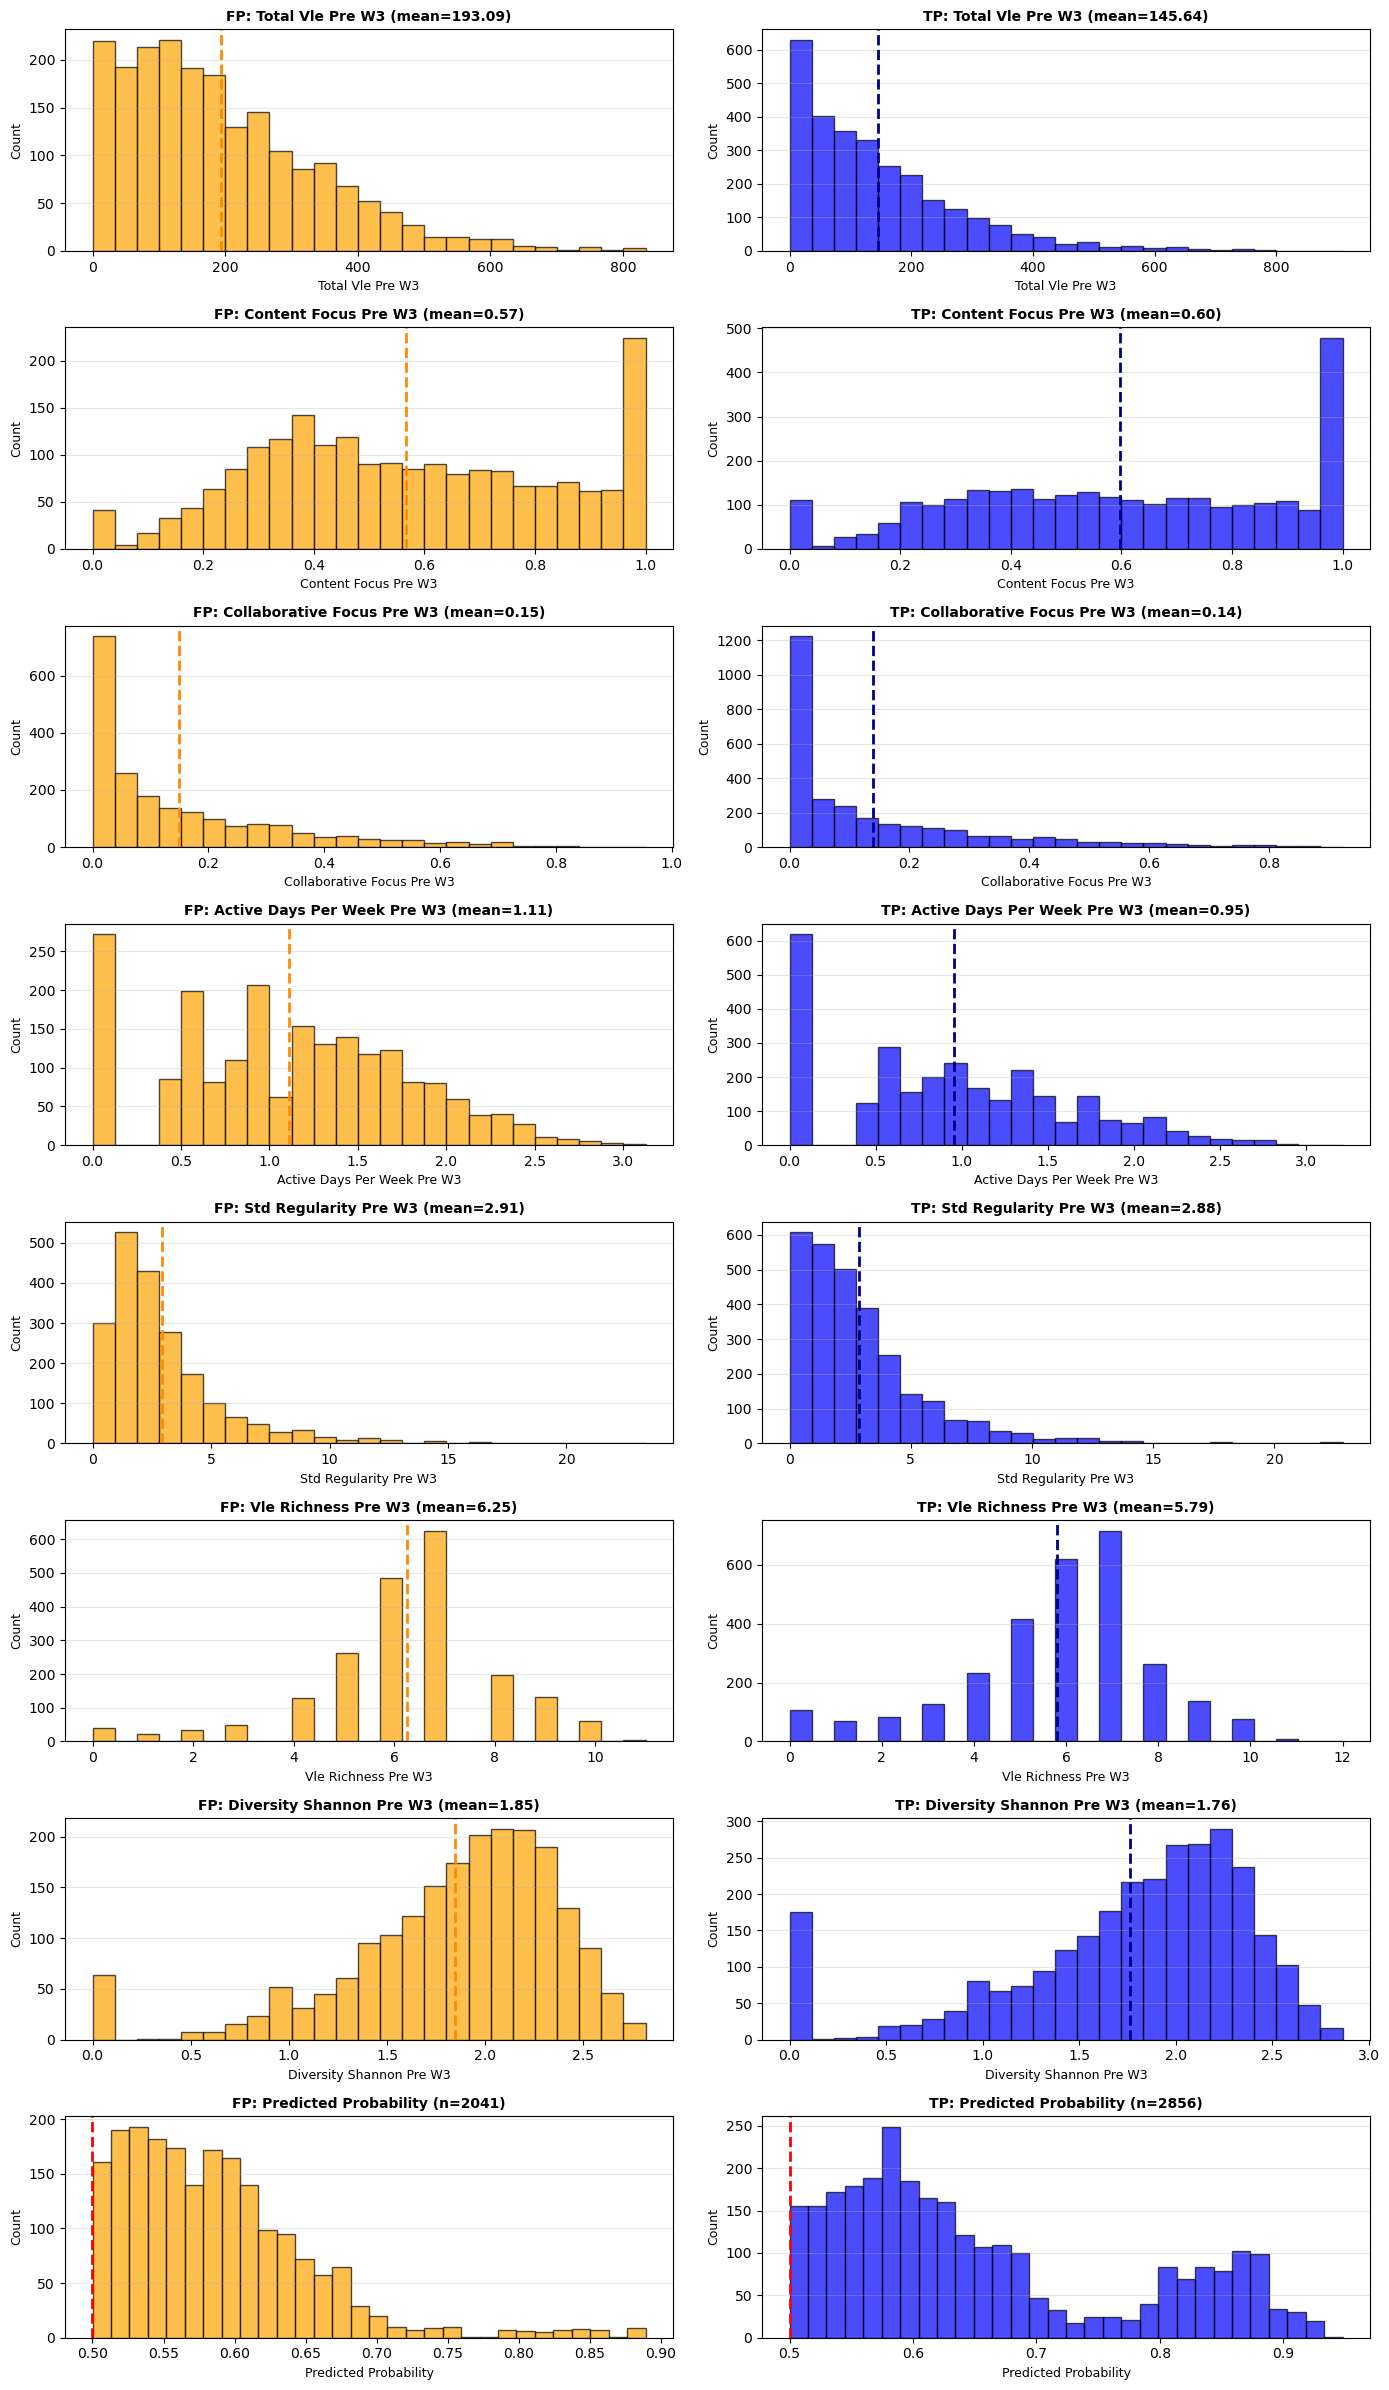


KEY INSIGHTS

Predicted Probabilities:
  FP Mean: 0.587
  TP Mean: 0.656

Most Different Features (FP vs TP):
  total_vle_pre_w3: FP are 47.45 higher than TP
  vle_richness_pre_w3: FP are 0.46 higher than TP
  active_days_per_week_pre_w3: FP are 0.16 higher than TP


In [37]:
# Get true positives from Logistic Regression model
y_train_numeric = y_train.apply(lambda x: int(x[0]))
y_pred = final_lr_model.predict(X_train)

# Identify true positives: predicted 1 (at-risk) and actual 1 (at-risk)
true_positive_mask = (y_pred == 1) & (y_train_numeric == 1)

true_positives = X_train[true_positive_mask].copy()
true_positives['actual_outcome'] = 'Fail/Withdrawn'
true_positives['predicted_outcome'] = 'At-Risk'
true_positives['predicted_probability'] = final_lr_model.predict_proba(X_train)[:, 1][true_positive_mask]

print(f"True Positives:  {len(true_positives)} students")
print(f"False Positives: {len(false_positives)} students")

# Compare feature means
feature_cols = ['total_vle_pre_w3', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
                'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 
                'vle_richness_pre_w3', 'diversity_shannon_pre_w3']

comparison = pd.DataFrame({
    'False Positives (FP)': false_positives[feature_cols].mean(),
    'True Positives (TP)': true_positives[feature_cols].mean()
})
comparison['Difference (FP - TP)'] = comparison['False Positives (FP)'] - comparison['True Positives (TP)']

print("\n" + "=" * 80)
print("FEATURE COMPARISON: False Positives vs True Positives")
print("=" * 80)
print(comparison.round(3).to_string())

# Side-by-side visualizations (FP on left, TP on right)
fig, axes = plt.subplots(8, 2, figsize=(14, 24))

# Features side-by-side
for idx, feature in enumerate(feature_cols):
    # False Positives (left column)
    axes[idx, 0].hist(false_positives[feature], bins=25, color='orange', edgecolor='black', alpha=0.7)
    axes[idx, 0].axvline(false_positives[feature].mean(), color='darkorange', linestyle='--', linewidth=2)
    axes[idx, 0].set_xlabel(feature.replace('_', ' ').title(), fontsize=9)
    axes[idx, 0].set_ylabel('Count', fontsize=9)
    axes[idx, 0].set_title(f'FP: {feature.replace("_", " ").title()} (mean={false_positives[feature].mean():.2f})', 
                           fontweight='bold', fontsize=10)
    axes[idx, 0].grid(alpha=0.3, axis='y')
    
    # True Positives (right column)
    axes[idx, 1].hist(true_positives[feature], bins=25, color='blue', edgecolor='black', alpha=0.7)
    axes[idx, 1].axvline(true_positives[feature].mean(), color='darkblue', linestyle='--', linewidth=2)
    axes[idx, 1].set_xlabel(feature.replace('_', ' ').title(), fontsize=9)
    axes[idx, 1].set_ylabel('Count', fontsize=9)
    axes[idx, 1].set_title(f'TP: {feature.replace("_", " ").title()} (mean={true_positives[feature].mean():.2f})', 
                           fontweight='bold', fontsize=10)
    axes[idx, 1].grid(alpha=0.3, axis='y')

# Predicted probability (row 7)
axes[7, 0].hist(false_positives['predicted_probability'], bins=30, color='orange', edgecolor='black', alpha=0.7)
axes[7, 0].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[7, 0].set_xlabel('Predicted Probability', fontsize=9)
axes[7, 0].set_ylabel('Count', fontsize=9)
axes[7, 0].set_title(f'FP: Predicted Probability (n={len(false_positives)})', fontweight='bold', fontsize=10)
axes[7, 0].grid(alpha=0.3, axis='y')

axes[7, 1].hist(true_positives['predicted_probability'], bins=30, color='blue', edgecolor='black', alpha=0.7)
axes[7, 1].axvline(x=0.5, color='red', linestyle='--', linewidth=2)
axes[7, 1].set_xlabel('Predicted Probability', fontsize=9)
axes[7, 1].set_ylabel('Count', fontsize=9)
axes[7, 1].set_title(f'TP: Predicted Probability (n={len(true_positives)})', fontweight='bold', fontsize=10)
axes[7, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Key insights
print("\n" + "=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

print(f"\nPredicted Probabilities:")
print(f"  FP Mean: {false_positives['predicted_probability'].mean():.3f}")
print(f"  TP Mean: {true_positives['predicted_probability'].mean():.3f}")

print(f"\nMost Different Features (FP vs TP):")
top_diffs = comparison['Difference (FP - TP)'].abs().nlargest(3)
for feat in top_diffs.index:
    diff = comparison.loc[feat, 'Difference (FP - TP)']
    direction = "higher" if diff > 0 else "lower"
    print(f"  {feat}: FP are {abs(diff):.2f} {direction} than TP")

STATISTICAL COMPARISON: False Positives vs True Positives
✓ Score added


Numerical Features:
------------------------------------------------------------------------------------------
                    Feature  FP Mean  TP Mean    Diff  p-value  Cohen's d Sig
                      score  75.8038  61.6178 14.1860   0.0000     0.6370 ***
           total_vle_pre_w3 193.0892 145.6397 47.4495   0.0000     0.3389 ***
active_days_per_week_pre_w3   1.1101   0.9530  0.1571   0.0000     0.2297 ***
        vle_richness_pre_w3   6.2513   5.7941  0.4572   0.0000     0.2232 ***
   diversity_shannon_pre_w3   1.8457   1.7620  0.0836   0.0000     0.1379 ***
       content_focus_pre_w3   0.5662   0.5983 -0.0320   0.0001    -0.1152 ***
 collaborative_focus_pre_w3   0.1490   0.1387  0.0103   0.0466     0.0578   *
      std_regularity_pre_w3   2.9131   2.8836  0.0295   0.7041     0.0111  ns


Categorical Feature (submission_type):
  Chi²=14.2989, p=0.0008, Cramér's V=0.0896
  FP: {'Early': 0.8740813326

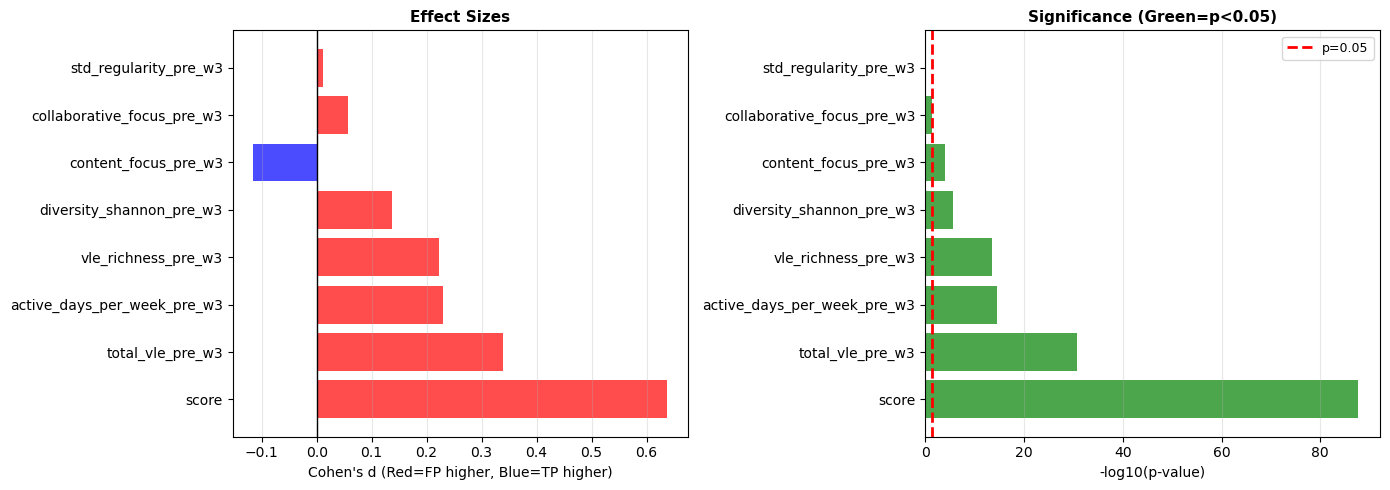

In [34]:
# Statistical analysis: FP vs TP (including submission_type and score)
from scipy import stats

print("=" * 90)
print("STATISTICAL COMPARISON: False Positives vs True Positives")
print("=" * 90)

# Add score if available
if 'score' in df.columns:
    false_positives['score'] = df.loc[false_positives.index, 'score']
    true_positives['score'] = df.loc[true_positives.index, 'score']
    print("✓ Score added\n")

# Numerical features
numerical_cols = ['total_vle_pre_w3', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
                  'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 
                  'vle_richness_pre_w3', 'diversity_shannon_pre_w3']
if 'score' in false_positives.columns:
    numerical_cols.append('score')

stats_results = []

# Analyze numerical features
for feature in numerical_cols:
    fp_vals = false_positives[feature].dropna()
    tp_vals = true_positives[feature].dropna()
    
    if len(fp_vals) == 0 or len(tp_vals) == 0:
        continue
    
    t_stat, p_val = stats.ttest_ind(fp_vals, tp_vals)
    pooled_std = np.sqrt((fp_vals.std()**2 + tp_vals.std()**2) / 2)
    cohens_d = (fp_vals.mean() - tp_vals.mean()) / pooled_std
    
    stats_results.append({
        'Feature': feature,
        'FP Mean': fp_vals.mean(),
        'TP Mean': tp_vals.mean(),
        'Diff': fp_vals.mean() - tp_vals.mean(),
        'p-value': p_val,
        'Cohen\'s d': cohens_d,
        'Sig': '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    })

# Analyze submission_type
contingency = pd.crosstab(
    pd.concat([false_positives['submission_type'], true_positives['submission_type']]),
    pd.Series(['FP']*len(false_positives) + ['TP']*len(true_positives))
)
chi2, chi_p, dof, expected = stats.chi2_contingency(contingency)
cramers_v = np.sqrt(chi2 / (contingency.sum().sum() * (min(contingency.shape) - 1)))

fp_sub = false_positives['submission_type'].value_counts(normalize=True)
tp_sub = true_positives['submission_type'].value_counts(normalize=True)

# Display results
stats_df = pd.DataFrame(stats_results).sort_values('p-value')
print("\nNumerical Features:")
print("-" * 90)
print(stats_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))

print("\n\nCategorical Feature (submission_type):")
print(f"  Chi²={chi2:.4f}, p={chi_p:.4f}, Cramér's V={cramers_v:.4f}")
print(f"  FP: {fp_sub.to_dict()}")
print(f"  TP: {tp_sub.to_dict()}")

# Key findings
print("\n" + "=" * 90)
print("KEY FINDINGS")
print("=" * 90)
sig = stats_df[stats_df['p-value'] < 0.05]
print(f"\n{len(sig)}/{len(stats_df)} features significantly different:")

for _, row in sig.iterrows():
    direction = "higher" if row['Diff'] > 0 else "lower"
    effect = "large" if abs(row['Cohen\'s d']) > 0.8 else "medium" if abs(row['Cohen\'s d']) > 0.5 else "small"
    print(f"  {row['Feature']}: FP {abs(row['Diff']):.2f} {direction} ({effect}, p={row['p-value']:.4f})")

if chi_p < 0.05:
    effect = "large" if cramers_v > 0.5 else "medium" if cramers_v > 0.3 else "small"
    print(f"  submission_type: Distributions differ ({effect}, p={chi_p:.4f})")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effect sizes
axes[0].barh(stats_df['Feature'], stats_df['Cohen\'s d'], 
             color=['red' if d > 0 else 'blue' for d in stats_df['Cohen\'s d']], alpha=0.7)
axes[0].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[0].set_xlabel("Cohen's d (Red=FP higher, Blue=TP higher)", fontsize=10)
axes[0].set_title("Effect Sizes", fontweight='bold', fontsize=11)
axes[0].grid(alpha=0.3, axis='x')

# P-values
colors = ['green' if p < 0.05 else 'gray' for p in stats_df['p-value']]
axes[1].barh(stats_df['Feature'], -np.log10(stats_df['p-value']), color=colors, alpha=0.7)
axes[1].axvline(x=-np.log10(0.05), color='red', linestyle='--', linewidth=2, label='p=0.05')
axes[1].set_xlabel("-log10(p-value)", fontsize=10)
axes[1].set_title("Significance (Green=p<0.05)", fontweight='bold', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

MEAN SCORE COMPARISON
False Positives (FP): 75.80
True Positives (TP):  61.62
Difference (FP - TP): +14.19


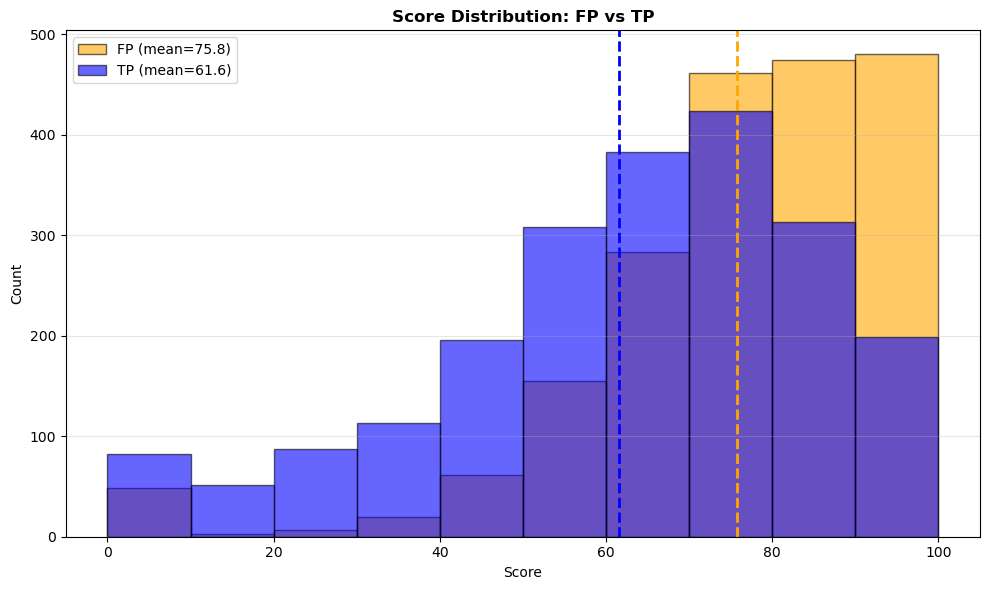

In [36]:
# Compare mean scores: FP vs TP
if 'score' in false_positives.columns:
    fp_score_mean = false_positives['score'].dropna().mean()
    tp_score_mean = true_positives['score'].dropna().mean()
    difference = fp_score_mean - tp_score_mean
    
    print("=" * 60)
    print("MEAN SCORE COMPARISON")
    print("=" * 60)
    print(f"False Positives (FP): {fp_score_mean:.2f}")
    print(f"True Positives (TP):  {tp_score_mean:.2f}")
    print(f"Difference (FP - TP): {difference:+.2f}")
    print("=" * 60)
else:
    print("Score not available in dataset")

if 'score' in false_positives.columns:
    plt.figure(figsize=(10, 6))
    fp_scores = false_positives['score'].dropna()
    tp_scores = true_positives['score'].dropna()
    
    plt.hist(fp_scores, bins=10, alpha=0.6, label=f'FP (mean={fp_scores.mean():.1f})', color='orange', edgecolor='black')
    plt.hist(tp_scores, bins=10, alpha=0.6, label=f'TP (mean={tp_scores.mean():.1f})', color='blue', edgecolor='black')
    plt.axvline(fp_scores.mean(), color='orange', linestyle='--', linewidth=2)
    plt.axvline(tp_scores.mean(), color='blue', linestyle='--', linewidth=2)
    
    plt.xlabel('Score')
    plt.ylabel('Count')
    plt.title('Score Distribution: FP vs TP', fontweight='bold')
    plt.legend()
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


## Threshold tuning

THRESHOLD TUNING RESULTS

Logistic Regression:
              Model  Threshold  Recall  Precision     F1   FN   FP
Logistic Regression     0.3000  0.9601     0.4457 0.6088  182 5439
Logistic Regression     0.3500  0.9151     0.4681 0.6194  387 4737
Logistic Regression     0.4000  0.8347     0.5063 0.6303  753 3709
Logistic Regression     0.4500  0.7302     0.5403 0.6211 1229 2831
Logistic Regression     0.5000  0.6269     0.5832 0.6043 1700 2041
Logistic Regression     0.5500  0.5059     0.6325 0.5622 2251 1339
Logistic Regression     0.6000  0.3565     0.6955 0.4713 2932  711

Random Forest:
        Model  Threshold  Recall  Precision     F1   FN   FP
Random Forest     0.3000  0.9539     0.4672 0.6272  210 4956
Random Forest     0.3500  0.9069     0.4976 0.6426  424 4172
Random Forest     0.4000  0.8279     0.5343 0.6494  784 3288
Random Forest     0.4500  0.7335     0.5731 0.6435 1214 2489
Random Forest     0.5000  0.6326     0.6187 0.6256 1674 1776
Random Forest     0.5500  0.5209   

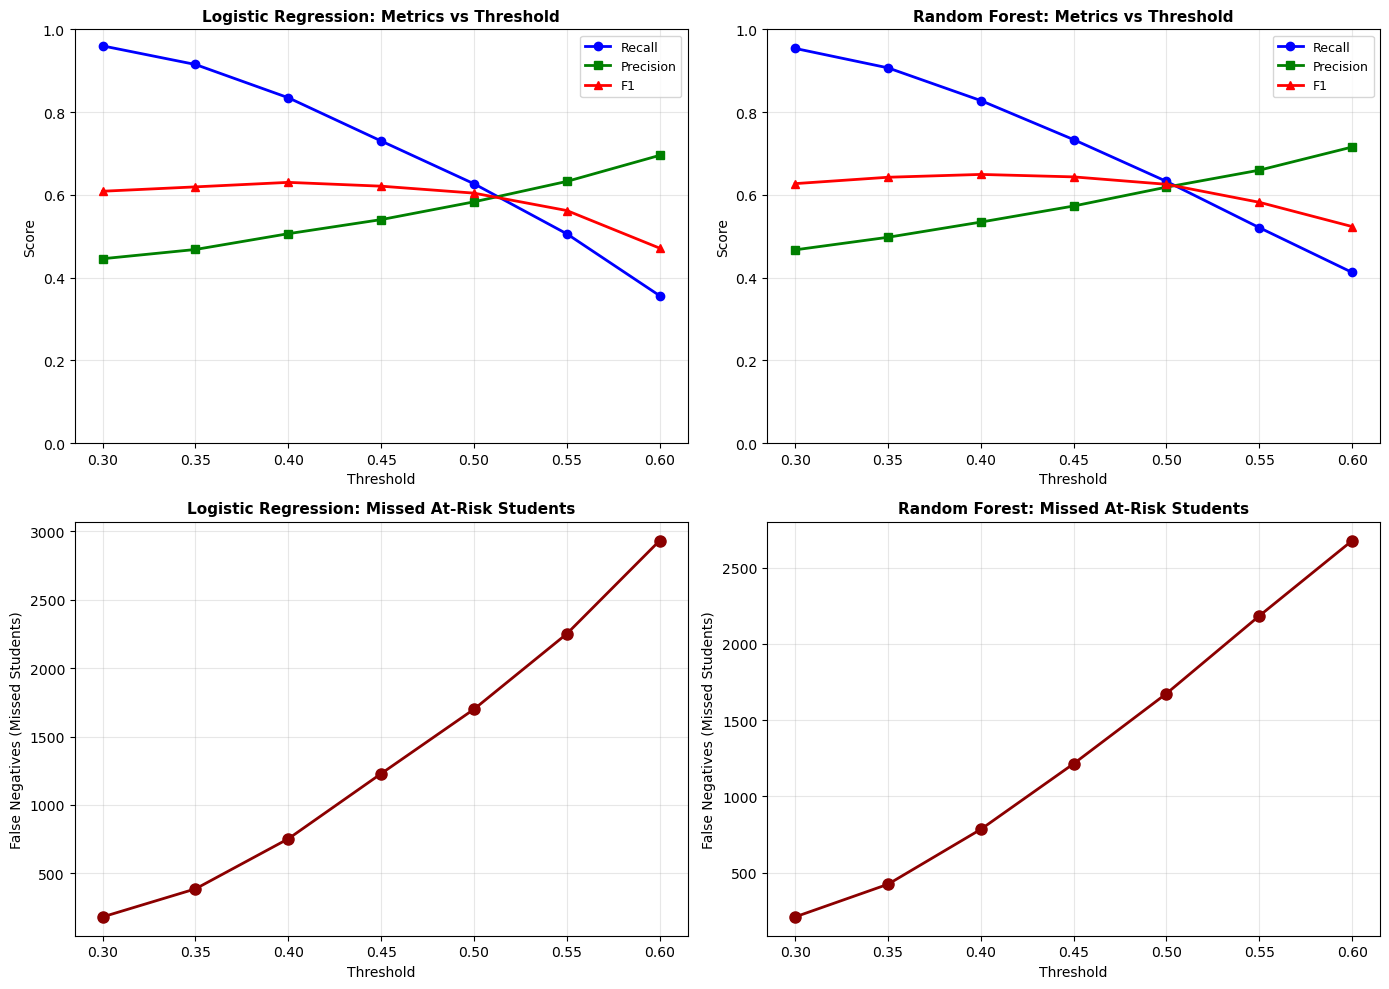


OPTIMAL THRESHOLDS

Logistic Regression:
  Best Recall:    threshold=0.30 → Recall=0.960, FN=182
  Best F1:        threshold=0.40 → F1=0.630, Recall=0.835

Random Forest:
  Best Recall:    threshold=0.30 → Recall=0.954, FN=210
  Best F1:        threshold=0.40 → F1=0.649, Recall=0.828


In [38]:
# Threshold tuning: LR and RF
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.3, 0.65, 0.05)
y_train_numeric = y_train.apply(lambda x: int(x[0]))

results = []

for model_name, model in [('Logistic Regression', final_lr_model), ('Random Forest', final_rf_model)]:
    y_proba = model.predict_proba(X_train)[:, 1]
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        cm = confusion_matrix(y_train_numeric, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            'Model': model_name,
            'Threshold': threshold,
            'Recall': recall_score(y_train_numeric, y_pred, zero_division=0),
            'Precision': precision_score(y_train_numeric, y_pred, zero_division=0),
            'F1': f1_score(y_train_numeric, y_pred, zero_division=0),
            'FN': fn,
            'FP': fp
        })

results_df = pd.DataFrame(results)

# Display
print("=" * 90)
print("THRESHOLD TUNING RESULTS")
print("=" * 90)
for model in ['Logistic Regression', 'Random Forest']:
    print(f"\n{model}:")
    print(results_df[results_df['Model'] == model].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for model_idx, model_name in enumerate(['Logistic Regression', 'Random Forest']):
    model_data = results_df[results_df['Model'] == model_name]
    
    # Recall, Precision, F1
    axes[0, model_idx].plot(model_data['Threshold'], model_data['Recall'], 'o-', linewidth=2, label='Recall', color='blue')
    axes[0, model_idx].plot(model_data['Threshold'], model_data['Precision'], 's-', linewidth=2, label='Precision', color='green')
    axes[0, model_idx].plot(model_data['Threshold'], model_data['F1'], '^-', linewidth=2, label='F1', color='red')
    axes[0, model_idx].set_xlabel('Threshold', fontsize=10)
    axes[0, model_idx].set_ylabel('Score', fontsize=10)
    axes[0, model_idx].set_title(f'{model_name}: Metrics vs Threshold', fontweight='bold', fontsize=11)
    axes[0, model_idx].legend(fontsize=9)
    axes[0, model_idx].grid(alpha=0.3)
    axes[0, model_idx].set_ylim([0, 1])
    
    # False Negatives
    axes[1, model_idx].plot(model_data['Threshold'], model_data['FN'], 'o-', linewidth=2, color='darkred', markersize=8)
    axes[1, model_idx].set_xlabel('Threshold', fontsize=10)
    axes[1, model_idx].set_ylabel('False Negatives (Missed Students)', fontsize=10)
    axes[1, model_idx].set_title(f'{model_name}: Missed At-Risk Students', fontweight='bold', fontsize=11)
    axes[1, model_idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Best thresholds
print("\n" + "=" * 90)
print("OPTIMAL THRESHOLDS")
print("=" * 90)
for model_name in ['Logistic Regression', 'Random Forest']:
    model_data = results_df[results_df['Model'] == model_name]
    best_recall = model_data.loc[model_data['Recall'].idxmax()]
    best_f1 = model_data.loc[model_data['F1'].idxmax()]
    
    print(f"\n{model_name}:")
    print(f"  Best Recall:    threshold={best_recall['Threshold']:.2f} → Recall={best_recall['Recall']:.3f}, FN={int(best_recall['FN'])}")
    print(f"  Best F1:        threshold={best_f1['Threshold']:.2f} → F1={best_f1['F1']:.3f}, Recall={best_f1['Recall']:.3f}")

THRESHOLD = 0.4
THRESHOLD = 0.45

RESULTS COMPARISON
 Threshold               Model  Recall  Precision     F1  ROC-AUC
    0.4000 Logistic Regression  0.8347     0.5063 0.6303   0.7088
    0.4000       Random Forest  0.8279     0.5343 0.6494   0.7423
    0.4500 Logistic Regression  0.7302     0.5403 0.6211   0.7088
    0.4500       Random Forest  0.7335     0.5731 0.6435   0.7423

CONFUSION MATRICES

--- Threshold = 0.4 ---

Logistic Regression:
  TN:  2,511  FP:  3,709
  FN:    753  TP:  3,803
  → Catches 83.5% of at-risk, 50.6% precision

Random Forest:
  TN:  2,932  FP:  3,288
  FN:    784  TP:  3,772
  → Catches 82.8% of at-risk, 53.4% precision

--- Threshold = 0.45 ---

Logistic Regression:
  TN:  3,389  FP:  2,831
  FN:  1,229  TP:  3,327
  → Catches 73.0% of at-risk, 54.0% precision

Random Forest:
  TN:  3,731  FP:  2,489
  FN:  1,214  TP:  3,342
  → Catches 73.4% of at-risk, 57.3% precision


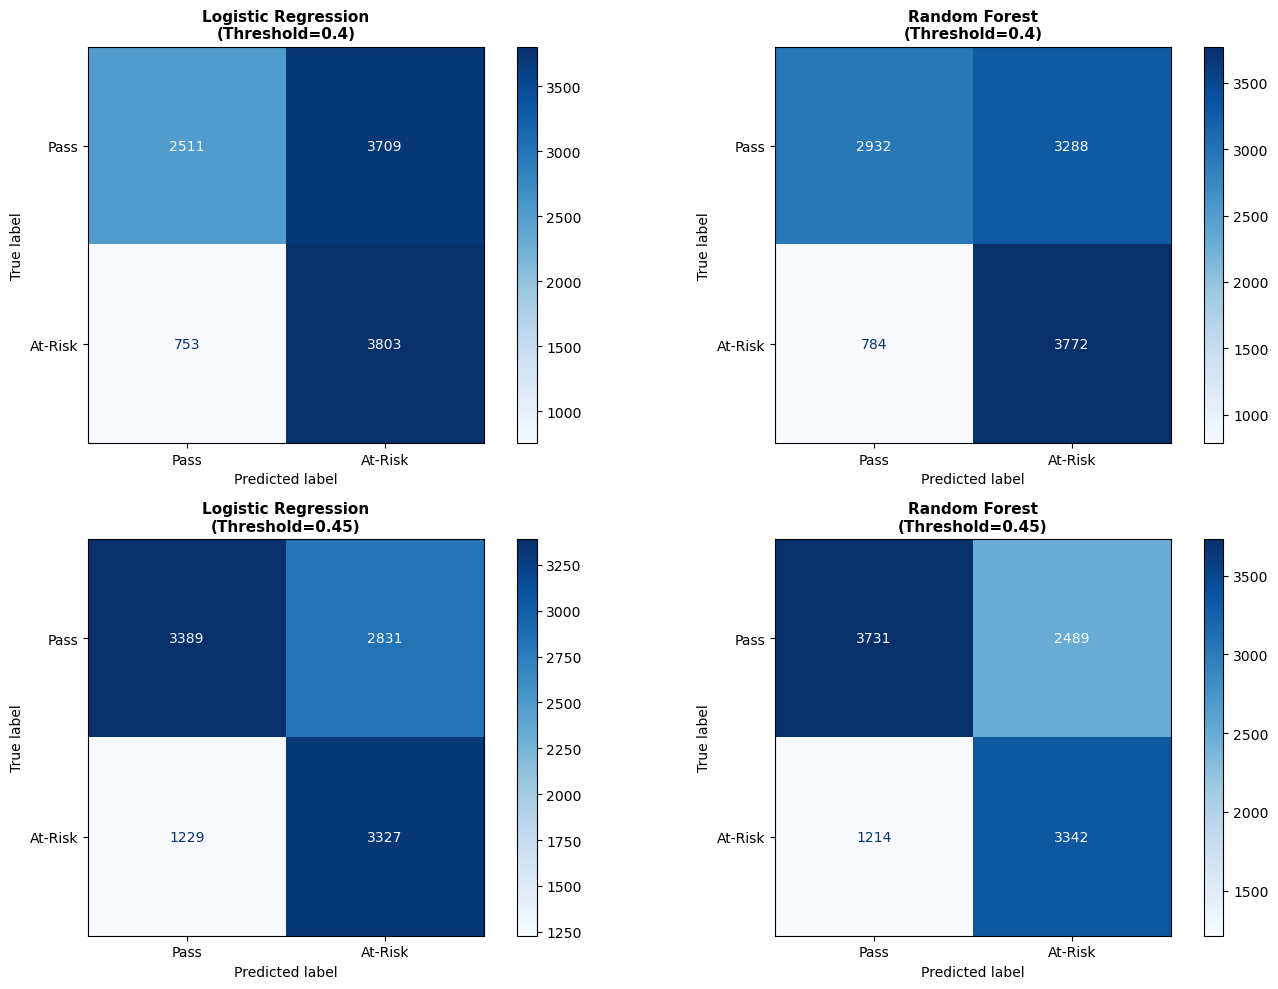


SUMMARY

Threshold 0.4:
  Best Recall: Logistic Regression (83.5%)
  Misses 753 / 4556 at-risk students
  3709 false alarms

Threshold 0.45:
  Best Recall: Random Forest (73.4%)
  Misses 1214 / 4556 at-risk students
  2489 false alarms


In [42]:
# Analyze LR and RF at thresholds 0.4 and 0.45
from sklearn.metrics import ConfusionMatrixDisplay

thresholds = [0.40, 0.45]
y_train_numeric = y_train.apply(lambda x: int(x[0]))

results = []

for threshold in thresholds:
    print("=" * 90)
    print(f"THRESHOLD = {threshold}")
    print("=" * 90)
    
    for model_name, model in [('Logistic Regression', final_lr_model), ('Random Forest', final_rf_model)]:
        y_proba = model.predict_proba(X_train)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        
        cm = confusion_matrix(y_train_numeric, y_pred)
        tn, fp, fn, tp = cm.ravel()
        
        results.append({
            'Threshold': threshold,
            'Model': model_name,
            'Recall': recall_score(y_train_numeric, y_pred),
            'Precision': precision_score(y_train_numeric, y_pred),
            'F1': f1_score(y_train_numeric, y_pred),
            'ROC-AUC': roc_auc_score(y_train_numeric, y_proba),
            'TN': tn, 'FP': fp, 'FN': fn, 'TP': tp
        })

results_df = pd.DataFrame(results)

# Display all results
print("\n" + "=" * 90)
print("RESULTS COMPARISON")
print("=" * 90)
print(results_df[['Threshold', 'Model', 'Recall', 'Precision', 'F1', 'ROC-AUC']].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

# Confusion matrices
print("\n" + "=" * 90)
print("CONFUSION MATRICES")
print("=" * 90)

for threshold in thresholds:
    print(f"\n--- Threshold = {threshold} ---")
    for model_name in ['Logistic Regression', 'Random Forest']:
        row = results_df[(results_df['Threshold'] == threshold) & (results_df['Model'] == model_name)].iloc[0]
        print(f"\n{model_name}:")
        print(f"  TN: {int(row['TN']):>6,}  FP: {int(row['FP']):>6,}")
        print(f"  FN: {int(row['FN']):>6,}  TP: {int(row['TP']):>6,}")
        print(f"  → Catches {row['Recall']:.1%} of at-risk, {row['Precision']:.1%} precision")

# Visualization - 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for thresh_idx, threshold in enumerate(thresholds):
    for model_idx, model_name in enumerate(['Logistic Regression', 'Random Forest']):
        row = results_df[(results_df['Threshold'] == threshold) & (results_df['Model'] == model_name)].iloc[0]
        cm = np.array([[row['TN'], row['FP']], [row['FN'], row['TP']]])
        
        ax = axes[thresh_idx, model_idx]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Pass', 'At-Risk'])
        disp.plot(cmap='Blues', ax=ax, values_format='d')
        ax.set_title(f'{model_name}\n(Threshold={threshold})', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Summary
print("\n" + "=" * 90)
print("SUMMARY")
print("=" * 90)

for threshold in thresholds:
    thresh_data = results_df[results_df['Threshold'] == threshold]
    best = thresh_data.loc[thresh_data['Recall'].idxmax()]
    print(f"\nThreshold {threshold}:")
    print(f"  Best Recall: {best['Model']} ({best['Recall']:.1%})")
    print(f"  Misses {int(best['FN'])} / {int(best['FN'] + best['TP'])} at-risk students")
    print(f"  {int(best['FP'])} false alarms")

THRESHOLD = 0.4

False Positives: 3709
True Positives:  3803

Feature                        FP Mean      TP Mean      Diff       p-value    Cohen's d 
------------------------------------------------------------------------------------------
total_vle_pre_w3               222.30       171.12       51.18      0.0000     0.288      ***
content_focus_pre_w3           0.62         0.62         -0.01      0.4102     -0.019     ns
collaborative_focus_pre_w3     0.19         0.16         0.02       0.0000     0.123      ***
active_days_per_week_pre_w3    1.12         1.00         0.11       0.0000     0.165      ***
std_regularity_pre_w3          2.65         2.76         -0.11      0.0409     -0.047     *
vle_richness_pre_w3            6.39         6.02         0.37       0.0000     0.183      ***
diversity_shannon_pre_w3       1.91         1.83         0.08       0.0000     0.142      ***
score                          74.77        62.80        11.97      0.0000     0.488      ***
THRESHOL

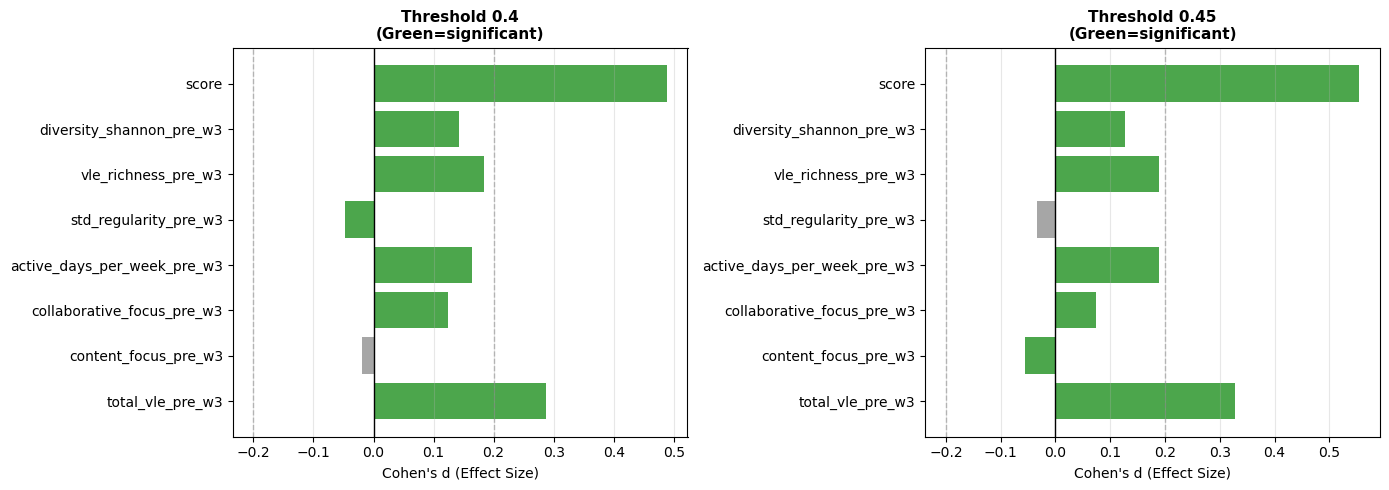


KEY INSIGHTS
Green bars = statistically significant differences (p<0.05)
Positive values = FP higher than TP
Negative values = TP higher than FP


In [43]:
# Compare FP and TP profiles: LR at thresholds 0.4 and 0.45
from scipy import stats

y_train_numeric = y_train.apply(lambda x: int(x[0]))
thresholds = [0.40, 0.45]

feature_cols = ['total_vle_pre_w3', 'content_focus_pre_w3', 'collaborative_focus_pre_w3',
                'active_days_per_week_pre_w3', 'std_regularity_pre_w3', 
                'vle_richness_pre_w3', 'diversity_shannon_pre_w3']

if 'score' in df.columns:
    feature_cols.append('score')

all_comparisons = []

for threshold in thresholds:
    print("=" * 90)
    print(f"THRESHOLD = {threshold}")
    print("=" * 90)
    
    # Get predictions
    y_proba = final_lr_model.predict_proba(X_train)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    # Identify FP and TP
    fp_mask = (y_pred == 1) & (y_train_numeric == 0)
    tp_mask = (y_pred == 1) & (y_train_numeric == 1)
    
    fp_data = X_train[fp_mask].copy()
    tp_data = X_train[tp_mask].copy()
    
    # Add score if available
    if 'score' in df.columns:
        fp_data['score'] = df.loc[fp_data.index, 'score']
        tp_data['score'] = df.loc[tp_data.index, 'score']
    
    print(f"\nFalse Positives: {len(fp_data)}")
    print(f"True Positives:  {len(tp_data)}")
    
    # Statistical comparison
    print(f"\n{'Feature':<30} {'FP Mean':<12} {'TP Mean':<12} {'Diff':<10} {'p-value':<10} {'Cohen\'s d':<10}")
    print("-" * 90)
    
    for feature in feature_cols:
        fp_vals = fp_data[feature].dropna()
        tp_vals = tp_data[feature].dropna()
        
        if len(fp_vals) == 0 or len(tp_vals) == 0:
            continue
        
        t_stat, p_val = stats.ttest_ind(fp_vals, tp_vals)
        pooled_std = np.sqrt((fp_vals.std()**2 + tp_vals.std()**2) / 2)
        cohens_d = (fp_vals.mean() - tp_vals.mean()) / pooled_std
        
        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
        
        print(f"{feature:<30} {fp_vals.mean():<12.2f} {tp_vals.mean():<12.2f} {fp_vals.mean()-tp_vals.mean():<10.2f} {p_val:<10.4f} {cohens_d:<10.3f} {sig}")
        
        all_comparisons.append({
            'Threshold': threshold,
            'Feature': feature,
            'FP Mean': fp_vals.mean(),
            'TP Mean': tp_vals.mean(),
            'Difference': fp_vals.mean() - tp_vals.mean(),
            'p-value': p_val,
            'Cohen\'s d': cohens_d,
            'Significant': sig
        })

# Compare thresholds
print("\n" + "=" * 90)
print("COMPARISON: THRESHOLD 0.4 vs 0.45")
print("=" * 90)

comparison_df = pd.DataFrame(all_comparisons)

for feature in feature_cols:
    t40 = comparison_df[(comparison_df['Threshold'] == 0.40) & (comparison_df['Feature'] == feature)].iloc[0]
    t45 = comparison_df[(comparison_df['Threshold'] == 0.45) & (comparison_df['Feature'] == feature)].iloc[0]
    
    print(f"\n{feature}:")
    print(f"  Threshold 0.40: Diff={t40['Difference']:>7.2f}, p={t40['p-value']:.4f}, d={t40['Cohen\'s d']:>6.3f} {t40['Significant']}")
    print(f"  Threshold 0.45: Diff={t45['Difference']:>7.2f}, p={t45['p-value']:.4f}, d={t45['Cohen\'s d']:>6.3f} {t45['Significant']}")
    
    if abs(t40['Difference']) > abs(t45['Difference']):
        print(f"  → Lower threshold (0.40) shows LARGER difference")
    elif abs(t40['Difference']) < abs(t45['Difference']):
        print(f"  → Higher threshold (0.45) shows LARGER difference")
    else:
        print(f"  → Similar difference at both thresholds")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, threshold in enumerate(thresholds):
    thresh_data = comparison_df[comparison_df['Threshold'] == threshold]
    
    colors = ['green' if s in ['***', '**', '*'] else 'gray' for s in thresh_data['Significant']]
    axes[idx].barh(thresh_data['Feature'], thresh_data['Cohen\'s d'], color=colors, alpha=0.7)
    axes[idx].axvline(x=0, color='black', linestyle='-', linewidth=1)
    axes[idx].axvline(x=0.2, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].axvline(x=-0.2, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    axes[idx].set_xlabel("Cohen's d (Effect Size)", fontsize=10)
    axes[idx].set_title(f'Threshold {threshold}\n(Green=significant)', fontweight='bold', fontsize=11)
    axes[idx].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("KEY INSIGHTS")
print("=" * 90)
print("Green bars = statistically significant differences (p<0.05)")
print("Positive values = FP higher than TP")
print("Negative values = TP higher than FP")

SCORE DISTRIBUTION COMPARISON: FP vs TP

THRESHOLD = 0.4

Statistic            False Positives      True Positives       Difference     
------------------------------------------------------------------------------------------
Mean                 74.77                62.80                11.97          
Median               78.00                67.00                11.00          
20th percentile      63.00                44.00                19.00          
40th percentile      75.00                61.00                14.00          
60th percentile      83.00                72.00                11.00          
80th percentile      92.00                84.00                8.00           

THRESHOLD = 0.45

Statistic            False Positives      True Positives       Difference     
------------------------------------------------------------------------------------------
Mean                 75.30                62.18                13.12          
Median               78.00    

/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_81505/1899975891.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['FP', 'TP'], patch_artist=True,
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_81505/1899975891.py:88: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[idx].boxplot(data_to_plot, labels=['FP', 'TP'], patch_artist=True,


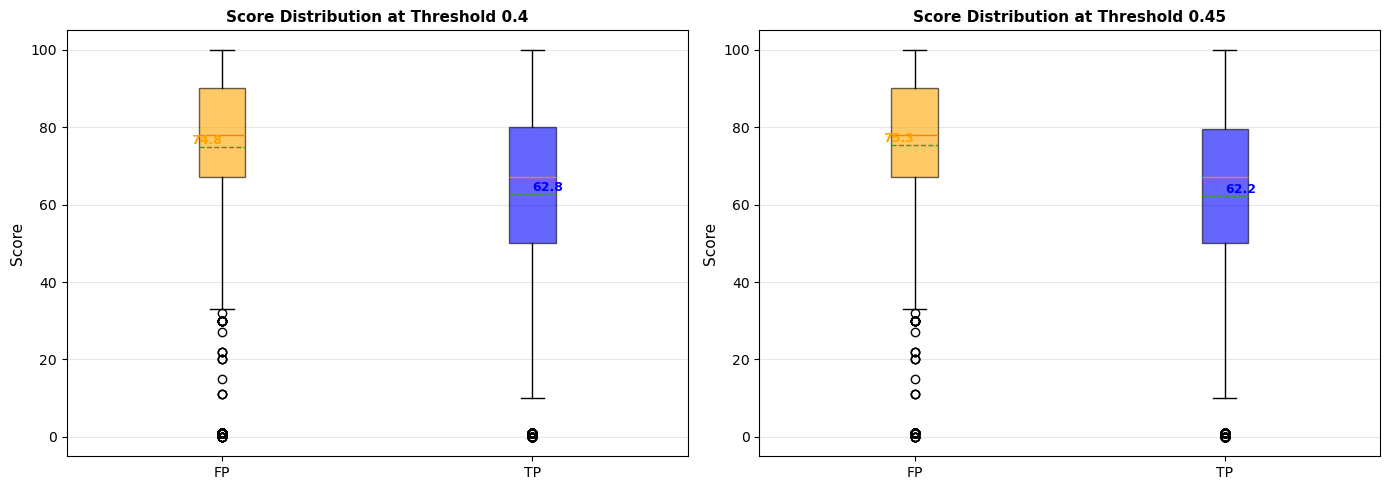


THRESHOLD COMPARISON SUMMARY

Statistic       Threshold 0.40            Threshold 0.45           
                FP       TP       Diff     FP       TP       Diff    
------------------------------------------------------------------------------------------
Mean            74.8     62.8     12.0     75.3     62.2     13.1    
Median          78.0     67.0     11.0     78.0     67.0     11.0    
Q20             63.0     44.0     19.0     62.0     44.0     18.0    
Q40             75.0     61.0     14.0     75.0     60.0     15.0    
Q60             83.0     72.0     11.0     83.0     70.0     13.0    
Q80             92.0     84.0     8.0      92.0     82.0     10.0    

KEY INSIGHT
False Positives consistently score HIGHER than True Positives across all quantiles.
This confirms FP students are higher performers incorrectly flagged as at-risk.


In [45]:
# Compare score quantiles: FP vs TP at thresholds 0.4 and 0.45
if 'score' in df.columns:
    y_train_numeric = y_train.apply(lambda x: int(x[0]))
    thresholds = [0.40, 0.45]
    
    print("=" * 90)
    print("SCORE DISTRIBUTION COMPARISON: FP vs TP")
    print("=" * 90)
    
    quantile_results = []
    
    for threshold in thresholds:
        # Get predictions
        y_proba = final_lr_model.predict_proba(X_train)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        
        # Identify FP and TP
        fp_mask = (y_pred == 1) & (y_train_numeric == 0)
        tp_mask = (y_pred == 1) & (y_train_numeric == 1)
        
        fp_scores = df.loc[X_train[fp_mask].index, 'score'].dropna()
        tp_scores = df.loc[X_train[tp_mask].index, 'score'].dropna()
        
        print(f"\n{'='*90}")
        print(f"THRESHOLD = {threshold}")
        print(f"{'='*90}")
        
        print(f"\n{'Statistic':<20} {'False Positives':<20} {'True Positives':<20} {'Difference':<15}")
        print("-" * 90)
        
        # Mean
        fp_mean = fp_scores.mean()
        tp_mean = tp_scores.mean()
        print(f"{'Mean':<20} {fp_mean:<20.2f} {tp_mean:<20.2f} {fp_mean - tp_mean:<15.2f}")
        
        # Median
        fp_median = fp_scores.median()
        tp_median = tp_scores.median()
        print(f"{'Median':<20} {fp_median:<20.2f} {tp_median:<20.2f} {fp_median - tp_median:<15.2f}")
        
        # Quantiles
        quantiles = [0.2, 0.4, 0.6, 0.8]
        for q in quantiles:
            fp_q = fp_scores.quantile(q)
            tp_q = tp_scores.quantile(q)
            print(f"{f'{int(q*100)}th percentile':<20} {fp_q:<20.2f} {tp_q:<20.2f} {fp_q - tp_q:<15.2f}")
            
            quantile_results.append({
                'Threshold': threshold,
                'Quantile': f'Q{int(q*100)}',
                'FP': fp_q,
                'TP': tp_q,
                'Difference': fp_q - tp_q
            })
        
        # Store mean and median
        quantile_results.append({
            'Threshold': threshold,
            'Quantile': 'Mean',
            'FP': fp_mean,
            'TP': tp_mean,
            'Difference': fp_mean - tp_mean
        })
        quantile_results.append({
            'Threshold': threshold,
            'Quantile': 'Median',
            'FP': fp_median,
            'TP': tp_median,
            'Difference': fp_median - tp_median
        })
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for idx, threshold in enumerate(thresholds):
        # Get predictions
        y_proba = final_lr_model.predict_proba(X_train)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        
        fp_mask = (y_pred == 1) & (y_train_numeric == 0)
        tp_mask = (y_pred == 1) & (y_train_numeric == 1)
        
        fp_scores = df.loc[X_train[fp_mask].index, 'score'].dropna()
        tp_scores = df.loc[X_train[tp_mask].index, 'score'].dropna()
        
        # Box plots
        data_to_plot = [fp_scores, tp_scores]
        bp = axes[idx].boxplot(data_to_plot, labels=['FP', 'TP'], patch_artist=True,
                                showmeans=True, meanline=True)
        
        # Color boxes
        bp['boxes'][0].set_facecolor('orange')
        bp['boxes'][0].set_alpha(0.6)
        bp['boxes'][1].set_facecolor('blue')
        bp['boxes'][1].set_alpha(0.6)
        
        axes[idx].set_ylabel('Score', fontsize=11)
        axes[idx].set_title(f'Score Distribution at Threshold {threshold}', fontweight='bold', fontsize=11)
        axes[idx].grid(alpha=0.3, axis='y')
        
        # Add mean values as text
        axes[idx].text(1, fp_scores.mean(), f'{fp_scores.mean():.1f}', 
                       ha='right', va='bottom', fontsize=9, color='orange', fontweight='bold')
        axes[idx].text(2, tp_scores.mean(), f'{tp_scores.mean():.1f}', 
                       ha='left', va='bottom', fontsize=9, color='blue', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    # Summary comparison
    print("\n" + "=" * 90)
    print("THRESHOLD COMPARISON SUMMARY")
    print("=" * 90)
    
    quantile_df = pd.DataFrame(quantile_results)
    
    stats_order = ['Mean', 'Median', 'Q20', 'Q40', 'Q60', 'Q80']
    
    print(f"\n{'Statistic':<15} {'Threshold 0.40':<25} {'Threshold 0.45':<25}")
    print(f"{'':15} {'FP':<8} {'TP':<8} {'Diff':<8} {'FP':<8} {'TP':<8} {'Diff':<8}")
    print("-" * 90)
    
    for stat in stats_order:
        t40 = quantile_df[(quantile_df['Threshold'] == 0.40) & (quantile_df['Quantile'] == stat)]
        t45 = quantile_df[(quantile_df['Threshold'] == 0.45) & (quantile_df['Quantile'] == stat)]
        
        if len(t40) > 0 and len(t45) > 0:
            t40 = t40.iloc[0]
            t45 = t45.iloc[0]
            print(f"{stat:<15} {t40['FP']:<8.1f} {t40['TP']:<8.1f} {t40['Difference']:<8.1f} "
                  f"{t45['FP']:<8.1f} {t45['TP']:<8.1f} {t45['Difference']:<8.1f}")
    
    print("\n" + "=" * 90)
    print("KEY INSIGHT")
    print("=" * 90)
    print("False Positives consistently score HIGHER than True Positives across all quantiles.")
    print("This confirms FP students are higher performers incorrectly flagged as at-risk.")

else:
    print("Score not available in dataset")

SCORE BREAKDOWN: FP AND TP BY THRESHOLD

THRESHOLD = 0.4

Total: FP = 3661, TP = 3102

Score Cutoff         FP Count        FP %            TP Count        TP %           
------------------------------------------------------------------------------------------
Score < 60           551             15.1          % 1091            35.2          %
Score < 65           785             21.4          % 1346            43.4          %
Score < 70           1015            27.7          % 1644            53.0          %
Score < 75           1403            38.3          % 1964            63.3          %

THRESHOLD = 0.45

Total: FP = 2783, TP = 2627

Score Cutoff         FP Count        FP %            TP Count        TP %           
------------------------------------------------------------------------------------------
Score < 60           425             15.3          % 965             36.7          %
Score < 65           607             21.8          % 1187            45.2          %
Sco

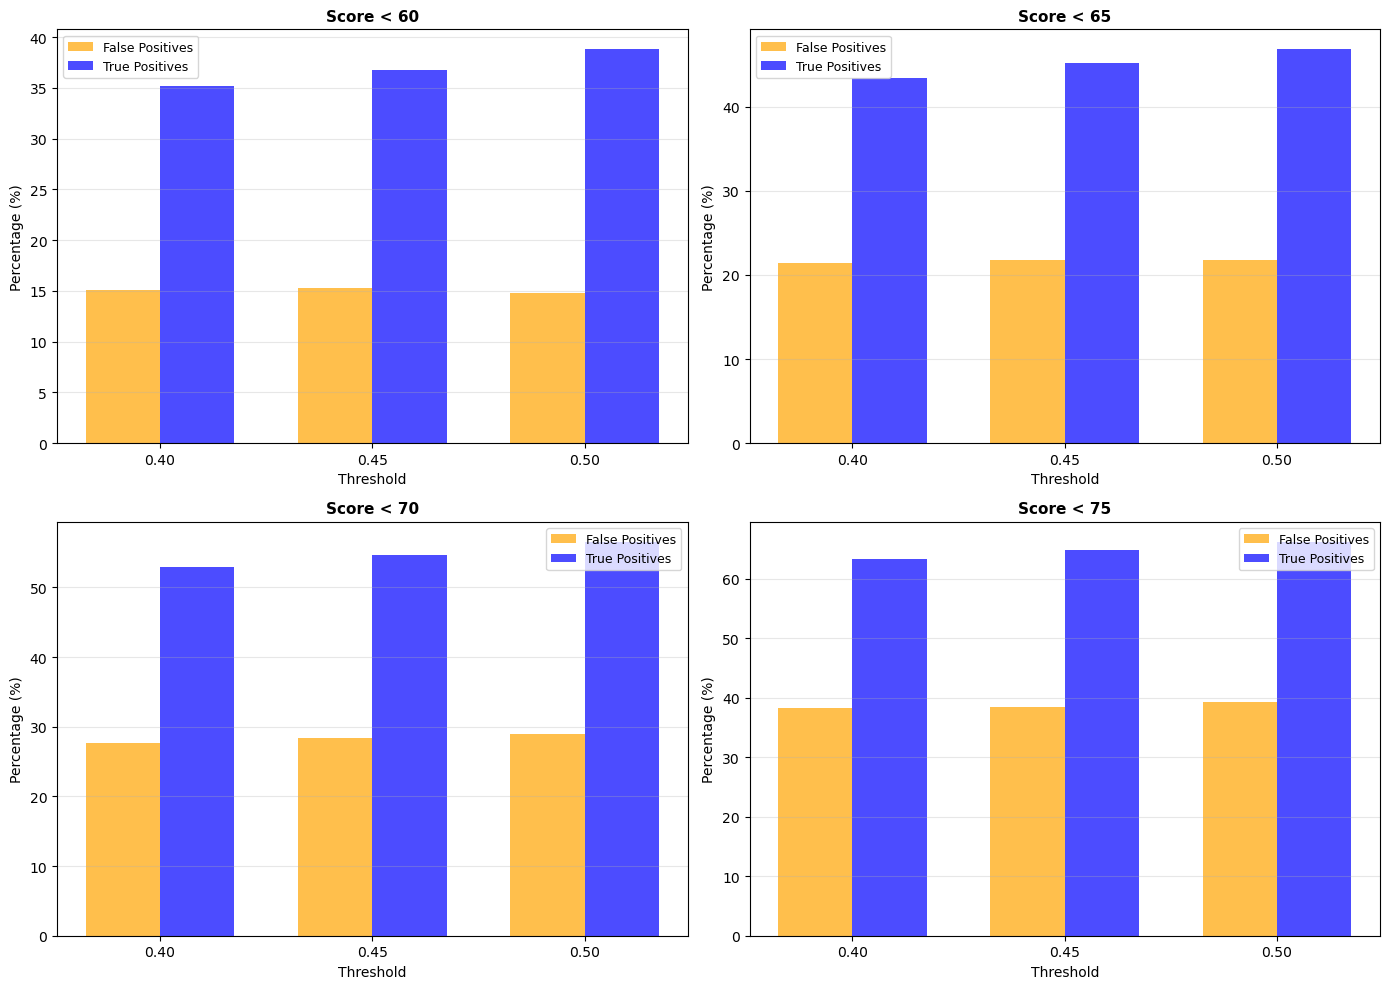


KEY INSIGHTS
• Higher % of TP have low scores compared to FP across all thresholds
• As threshold increases, fewer total students flagged (both FP and TP)
• FP students consistently score higher than TP students


In [46]:
# Score breakdown: FP and TP at thresholds 0.4, 0.45, 0.5
if 'score' in df.columns:
    y_train_numeric = y_train.apply(lambda x: int(x[0]))
    thresholds = [0.40, 0.45, 0.50]
    score_cutoffs = [60, 65, 70, 75]
    
    print("=" * 90)
    print("SCORE BREAKDOWN: FP AND TP BY THRESHOLD")
    print("=" * 90)
    
    all_results = []
    
    for threshold in thresholds:
        print(f"\n{'='*90}")
        print(f"THRESHOLD = {threshold}")
        print(f"{'='*90}")
        
        # Get predictions
        y_proba = final_lr_model.predict_proba(X_train)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        
        # Identify FP and TP
        fp_mask = (y_pred == 1) & (y_train_numeric == 0)
        tp_mask = (y_pred == 1) & (y_train_numeric == 1)
        
        fp_scores = df.loc[X_train[fp_mask].index, 'score'].dropna()
        tp_scores = df.loc[X_train[tp_mask].index, 'score'].dropna()
        
        print(f"\nTotal: FP = {len(fp_scores)}, TP = {len(tp_scores)}")
        print(f"\n{'Score Cutoff':<20} {'FP Count':<15} {'FP %':<15} {'TP Count':<15} {'TP %':<15}")
        print("-" * 90)
        
        for cutoff in score_cutoffs:
            fp_count = (fp_scores < cutoff).sum()
            tp_count = (tp_scores < cutoff).sum()
            fp_pct = fp_count / len(fp_scores) * 100 if len(fp_scores) > 0 else 0
            tp_pct = tp_count / len(tp_scores) * 100 if len(tp_scores) > 0 else 0
            
            print(f"{'Score < ' + str(cutoff):<20} {fp_count:<15} {fp_pct:<14.1f}% {tp_count:<15} {tp_pct:<14.1f}%")
            
            all_results.append({
                'Threshold': threshold,
                'Cutoff': cutoff,
                'FP Count': fp_count,
                'FP %': fp_pct,
                'TP Count': tp_count,
                'TP %': tp_pct
            })
    
    # Summary comparison
    print("\n" + "=" * 90)
    print("SUMMARY: COMPARISON ACROSS THRESHOLDS")
    print("=" * 90)
    
    results_df = pd.DataFrame(all_results)
    
    for cutoff in score_cutoffs:
        print(f"\nScore < {cutoff}:")
        cutoff_data = results_df[results_df['Cutoff'] == cutoff]
        print(f"{'Threshold':<12} {'FP Count':<12} {'FP %':<12} {'TP Count':<12} {'TP %':<12}")
        print("-" * 60)
        for _, row in cutoff_data.iterrows():
            print(f"{row['Threshold']:<12} {int(row['FP Count']):<12} {row['FP %']:<11.1f}% {int(row['TP Count']):<12} {row['TP %']:<11.1f}%")
    
    # Visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for idx, cutoff in enumerate(score_cutoffs):
        cutoff_data = results_df[results_df['Cutoff'] == cutoff]
        
        x = np.arange(len(thresholds))
        width = 0.35
        
        axes[idx].bar(x - width/2, cutoff_data['FP %'], width, label='False Positives', color='orange', alpha=0.7)
        axes[idx].bar(x + width/2, cutoff_data['TP %'], width, label='True Positives', color='blue', alpha=0.7)
        
        axes[idx].set_xlabel('Threshold', fontsize=10)
        axes[idx].set_ylabel('Percentage (%)', fontsize=10)
        axes[idx].set_title(f'Score < {cutoff}', fontweight='bold', fontsize=11)
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels([f'{t:.2f}' for t in thresholds])
        axes[idx].legend(fontsize=9)
        axes[idx].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()
    
    print("\n" + "=" * 90)
    print("KEY INSIGHTS")
    print("=" * 90)
    print("• Higher % of TP have low scores compared to FP across all thresholds")
    print("• As threshold increases, fewer total students flagged (both FP and TP)")
    print("• FP students consistently score higher than TP students")

else:
    print("Score not available in dataset")

QUANTILE DISTRIBUTION ANALYSIS: VLE FEATURES

FEATURE: TOTAL_VLE_PRE_W3

--- Threshold = 0.4 ---
Statistic            False Positives      True Positives       Difference     
---------------------------------------------------------------------------
Mean                 222.30               171.12               51.18          
Median               166.00               121.00               45.00          
20th percentile      64.00                38.00                26.00          
40th percentile      126.00               89.00                37.00          
60th percentile      222.00               158.20               63.80          
80th percentile      369.40               277.00               92.40          

--- Threshold = 0.45 ---
Statistic            False Positives      True Positives       Difference     
---------------------------------------------------------------------------
Mean                 213.76               160.06               53.70          
Median        

/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_81505/3060122548.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['FP', 'TP'], patch_artist=True,
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_81505/3060122548.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['FP', 'TP'], patch_artist=True,
/var/folders/1v/h2vyfq9j45n9_tmm_gg2s8tm0000gn/T/ipykernel_81505/3060122548.py:61: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, labels=['FP', 'TP'], patch_artist=True,
/var/folders/1v/h2vyfq9j45n9

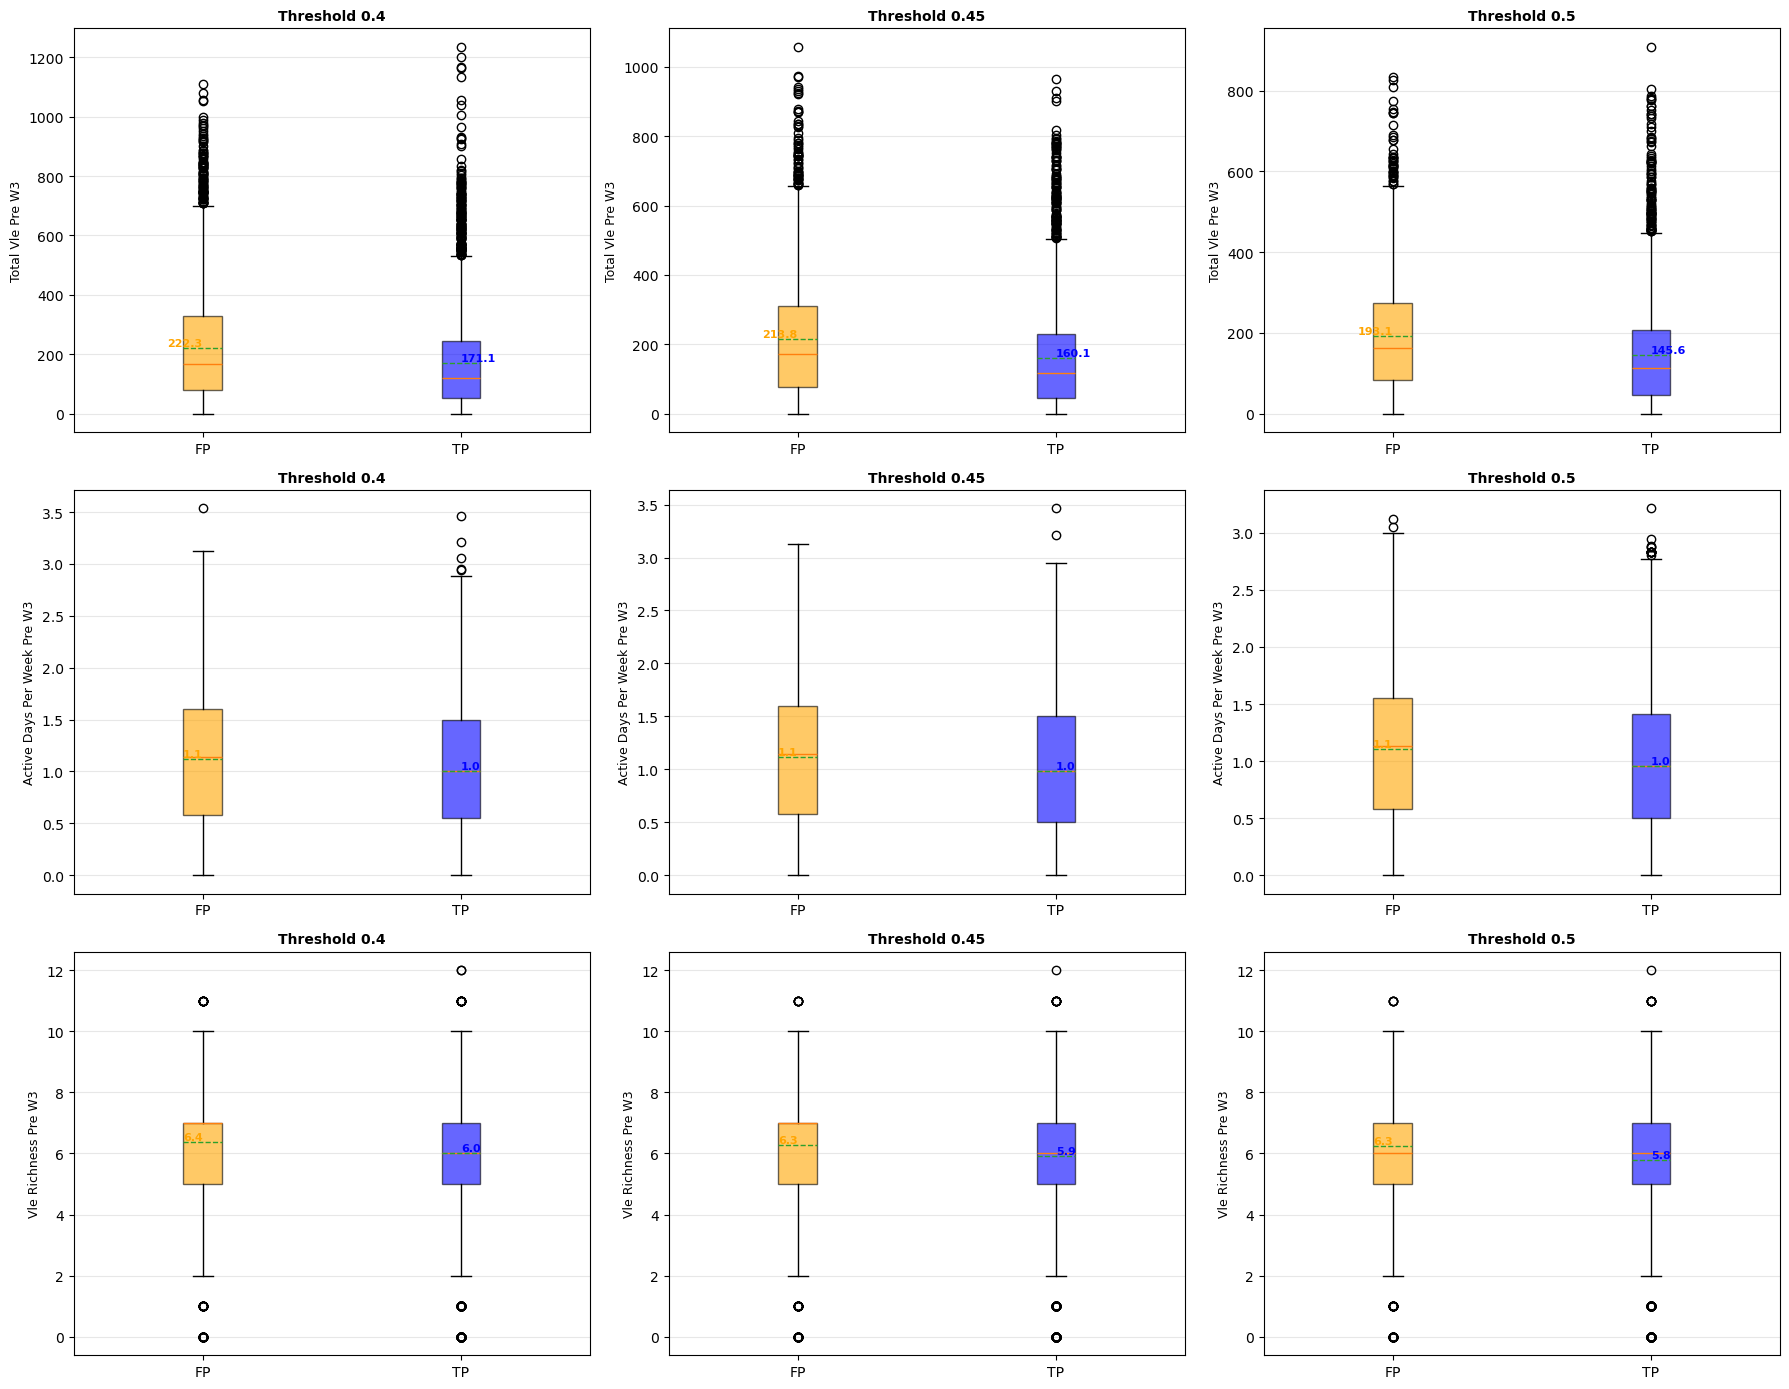


KEY INSIGHTS
• False Positives show HIGHER engagement across all VLE metrics
• This pattern is consistent across all thresholds (0.4, 0.45, 0.5)
• FP students are more active but still flagged as at-risk
• Model may be flagging 'moderately engaged' students incorrectly


In [47]:
# Quantile distribution analysis: VLE features for FP vs TP
y_train_numeric = y_train.apply(lambda x: int(x[0]))
thresholds = [0.40, 0.45, 0.50]
features = ['total_vle_pre_w3', 'active_days_per_week_pre_w3', 'vle_richness_pre_w3']
quantiles = [0.2, 0.4, 0.6, 0.8]

print("=" * 90)
print("QUANTILE DISTRIBUTION ANALYSIS: VLE FEATURES")
print("=" * 90)

for feature in features:
    print(f"\n{'='*90}")
    print(f"FEATURE: {feature.upper()}")
    print(f"{'='*90}")
    
    for threshold in thresholds:
        # Get predictions
        y_proba = final_lr_model.predict_proba(X_train)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        
        # Identify FP and TP
        fp_mask = (y_pred == 1) & (y_train_numeric == 0)
        tp_mask = (y_pred == 1) & (y_train_numeric == 1)
        
        fp_values = X_train.loc[fp_mask, feature]
        tp_values = X_train.loc[tp_mask, feature]
        
        print(f"\n--- Threshold = {threshold} ---")
        print(f"{'Statistic':<20} {'False Positives':<20} {'True Positives':<20} {'Difference':<15}")
        print("-" * 75)
        
        # Mean and Median
        print(f"{'Mean':<20} {fp_values.mean():<20.2f} {tp_values.mean():<20.2f} {fp_values.mean() - tp_values.mean():<15.2f}")
        print(f"{'Median':<20} {fp_values.median():<20.2f} {tp_values.median():<20.2f} {fp_values.median() - tp_values.median():<15.2f}")
        
        # Quantiles
        for q in quantiles:
            fp_q = fp_values.quantile(q)
            tp_q = tp_values.quantile(q)
            print(f"{f'{int(q*100)}th percentile':<20} {fp_q:<20.2f} {tp_q:<20.2f} {fp_q - tp_q:<15.2f}")

# Visualization
fig, axes = plt.subplots(3, 3, figsize=(18, 14))

for feat_idx, feature in enumerate(features):
    for thresh_idx, threshold in enumerate(thresholds):
        # Get predictions
        y_proba = final_lr_model.predict_proba(X_train)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        
        fp_mask = (y_pred == 1) & (y_train_numeric == 0)
        tp_mask = (y_pred == 1) & (y_train_numeric == 1)
        
        fp_values = X_train.loc[fp_mask, feature]
        tp_values = X_train.loc[tp_mask, feature]
        
        ax = axes[feat_idx, thresh_idx]
        
        # Box plots
        data_to_plot = [fp_values, tp_values]
        bp = ax.boxplot(data_to_plot, labels=['FP', 'TP'], patch_artist=True,
                        showmeans=True, meanline=True)
        
        bp['boxes'][0].set_facecolor('orange')
        bp['boxes'][0].set_alpha(0.6)
        bp['boxes'][1].set_facecolor('blue')
        bp['boxes'][1].set_alpha(0.6)
        
        ax.set_ylabel(feature.replace('_', ' ').title(), fontsize=9)
        ax.set_title(f'Threshold {threshold}', fontweight='bold', fontsize=10)
        ax.grid(alpha=0.3, axis='y')
        
        # Add mean values
        ax.text(1, fp_values.mean(), f'{fp_values.mean():.1f}', 
                ha='right', va='bottom', fontsize=8, color='orange', fontweight='bold')
        ax.text(2, tp_values.mean(), f'{tp_values.mean():.1f}', 
                ha='left', va='bottom', fontsize=8, color='blue', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("KEY INSIGHTS")
print("=" * 90)
print("• False Positives show HIGHER engagement across all VLE metrics")
print("• This pattern is consistent across all thresholds (0.4, 0.45, 0.5)")
print("• FP students are more active but still flagged as at-risk")
print("• Model may be flagging 'moderately engaged' students incorrectly")

SUBMISSION TYPE DISTRIBUTION: FP vs TP

THRESHOLD = 0.4

False Positives (Total: 3709):
Submission Type      Count           Percentage     
--------------------------------------------------
Early                2281            61.5          %
Late                 1381            37.2          %
Never                47              1.3           %

True Positives (Total: 3803):
Submission Type      Count           Percentage     
--------------------------------------------------
Early                2207            58.0          %
Late                 907             23.8          %
Never                689             18.1          %

THRESHOLD = 0.45

False Positives (Total: 2831):
Submission Type      Count           Percentage     
--------------------------------------------------
Early                2125            75.1          %
Late                 659             23.3          %
Never                47              1.7           %

True Positives (Total: 3327):
Submission 

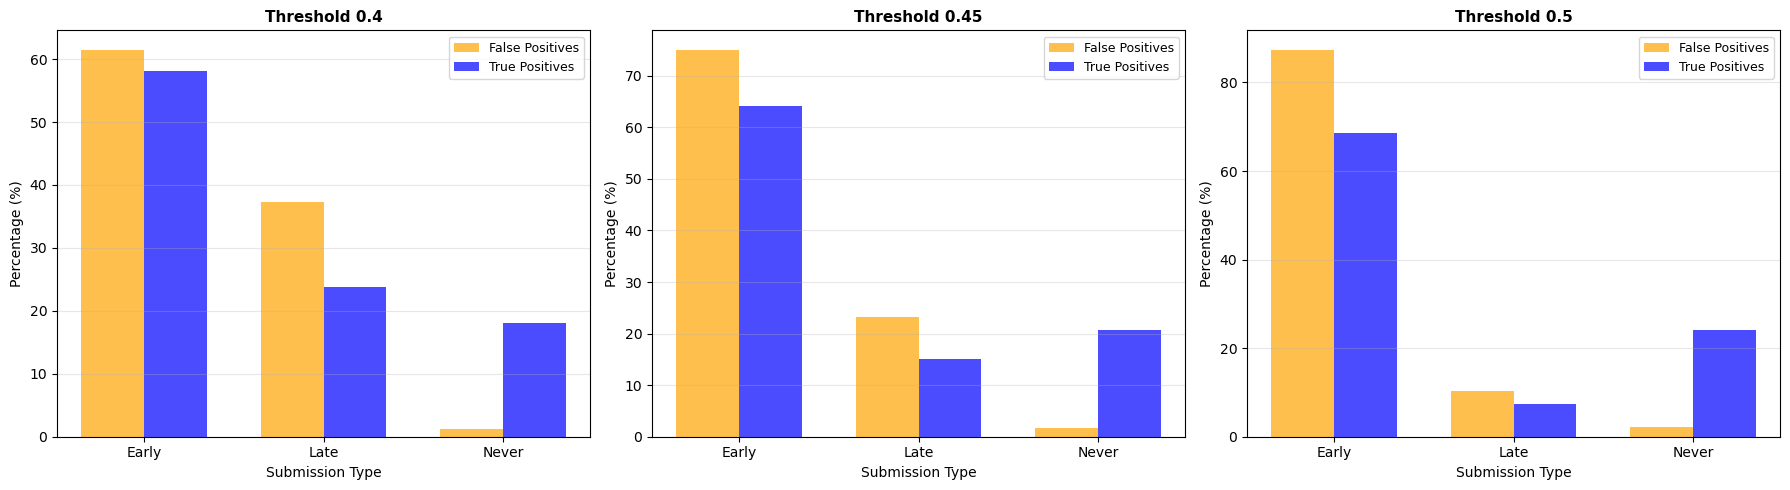


KEY INSIGHTS
• FP students submit EARLY much more often than TP students
• TP students have much higher 'Never' submitted rate
• Pattern consistent across all thresholds
• 'Never' submission is a strong indicator of true at-risk status


In [48]:
# Submission type distribution: FP vs TP at thresholds 0.4, 0.45, 0.5
y_train_numeric = y_train.apply(lambda x: int(x[0]))
thresholds = [0.40, 0.45, 0.50]

print("=" * 90)
print("SUBMISSION TYPE DISTRIBUTION: FP vs TP")
print("=" * 90)

all_results = []

for threshold in thresholds:
    print(f"\n{'='*90}")
    print(f"THRESHOLD = {threshold}")
    print(f"{'='*90}")
    
    # Get predictions
    y_proba = final_lr_model.predict_proba(X_train)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    # Identify FP and TP
    fp_mask = (y_pred == 1) & (y_train_numeric == 0)
    tp_mask = (y_pred == 1) & (y_train_numeric == 1)
    
    fp_submission = X_train.loc[fp_mask, 'submission_type']
    tp_submission = X_train.loc[tp_mask, 'submission_type']
    
    # Count and percentages
    fp_counts = fp_submission.value_counts().sort_index()
    tp_counts = tp_submission.value_counts().sort_index()
    
    fp_pcts = fp_submission.value_counts(normalize=True).sort_index() * 100
    tp_pcts = tp_submission.value_counts(normalize=True).sort_index() * 100
    
    print(f"\nFalse Positives (Total: {len(fp_submission)}):")
    print(f"{'Submission Type':<20} {'Count':<15} {'Percentage':<15}")
    print("-" * 50)
    for sub_type in ['Early', 'Late', 'Never']:
        count = fp_counts.get(sub_type, 0)
        pct = fp_pcts.get(sub_type, 0)
        print(f"{sub_type:<20} {count:<15} {pct:<14.1f}%")
        
        all_results.append({
            'Threshold': threshold,
            'Group': 'FP',
            'Submission Type': sub_type,
            'Count': count,
            'Percentage': pct
        })
    
    print(f"\nTrue Positives (Total: {len(tp_submission)}):")
    print(f"{'Submission Type':<20} {'Count':<15} {'Percentage':<15}")
    print("-" * 50)
    for sub_type in ['Early', 'Late', 'Never']:
        count = tp_counts.get(sub_type, 0)
        pct = tp_pcts.get(sub_type, 0)
        print(f"{sub_type:<20} {count:<15} {pct:<14.1f}%")
        
        all_results.append({
            'Threshold': threshold,
            'Group': 'TP',
            'Submission Type': sub_type,
            'Count': count,
            'Percentage': pct
        })

# Summary table
print("\n" + "=" * 90)
print("SUMMARY: COMPARISON ACROSS THRESHOLDS")
print("=" * 90)

results_df = pd.DataFrame(all_results)

for sub_type in ['Early', 'Late', 'Never']:
    print(f"\n{sub_type} Submissions:")
    print(f"{'Threshold':<12} {'FP Count':<12} {'FP %':<12} {'TP Count':<12} {'TP %':<12}")
    print("-" * 60)
    
    for threshold in thresholds:
        fp_data = results_df[(results_df['Threshold'] == threshold) & 
                             (results_df['Group'] == 'FP') & 
                             (results_df['Submission Type'] == sub_type)]
        tp_data = results_df[(results_df['Threshold'] == threshold) & 
                             (results_df['Group'] == 'TP') & 
                             (results_df['Submission Type'] == sub_type)]
        
        if len(fp_data) > 0 and len(tp_data) > 0:
            fp_row = fp_data.iloc[0]
            tp_row = tp_data.iloc[0]
            print(f"{threshold:<12} {int(fp_row['Count']):<12} {fp_row['Percentage']:<11.1f}% "
                  f"{int(tp_row['Count']):<12} {tp_row['Percentage']:<11.1f}%")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, threshold in enumerate(thresholds):
    thresh_data = results_df[results_df['Threshold'] == threshold]
    
    # Prepare data for grouped bar chart
    fp_data = thresh_data[thresh_data['Group'] == 'FP'].set_index('Submission Type')['Percentage']
    tp_data = thresh_data[thresh_data['Group'] == 'TP'].set_index('Submission Type')['Percentage']
    
    x = np.arange(3)
    width = 0.35
    
    axes[idx].bar(x - width/2, [fp_data.get('Early', 0), fp_data.get('Late', 0), fp_data.get('Never', 0)], 
                  width, label='False Positives', color='orange', alpha=0.7)
    axes[idx].bar(x + width/2, [tp_data.get('Early', 0), tp_data.get('Late', 0), tp_data.get('Never', 0)], 
                  width, label='True Positives', color='blue', alpha=0.7)
    
    axes[idx].set_xlabel('Submission Type', fontsize=10)
    axes[idx].set_ylabel('Percentage (%)', fontsize=10)
    axes[idx].set_title(f'Threshold {threshold}', fontweight='bold', fontsize=11)
    axes[idx].set_xticks(x)
    axes[idx].set_xticklabels(['Early', 'Late', 'Never'])
    axes[idx].legend(fontsize=9)
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("KEY INSIGHTS")
print("=" * 90)
print("• FP students submit EARLY much more often than TP students")
print("• TP students have much higher 'Never' submitted rate")
print("• Pattern consistent across all thresholds")
print("• 'Never' submission is a strong indicator of true at-risk status")

FALSE POSITIVE STUDENTS WITH AT-RISK INDICATORS

Threshold = 0.40
  Total False Positives: 3709
  FP with ≥1 risk factor: 2358 (63.6%)
    • Late/Never submission: 1428 (38.5%)
    • Score < 70: 1015 (27.4%)
    • VLE interactions ≤ 112.5: 1341 (36.2%)

Threshold = 0.45
  Total False Positives: 2831
  FP with ≥1 risk factor: 1605 (56.7%)
    • Late/Never submission: 706 (24.9%)
    • Score < 70: 788 (27.8%)
    • VLE interactions ≤ 112.5: 1001 (35.4%)

Threshold = 0.50
  Total False Positives: 2041
  FP with ≥1 risk factor: 1078 (52.8%)
    • Late/Never submission: 257 (12.6%)
    • Score < 70: 577 (28.3%)
    • VLE interactions ≤ 112.5: 710 (34.8%)


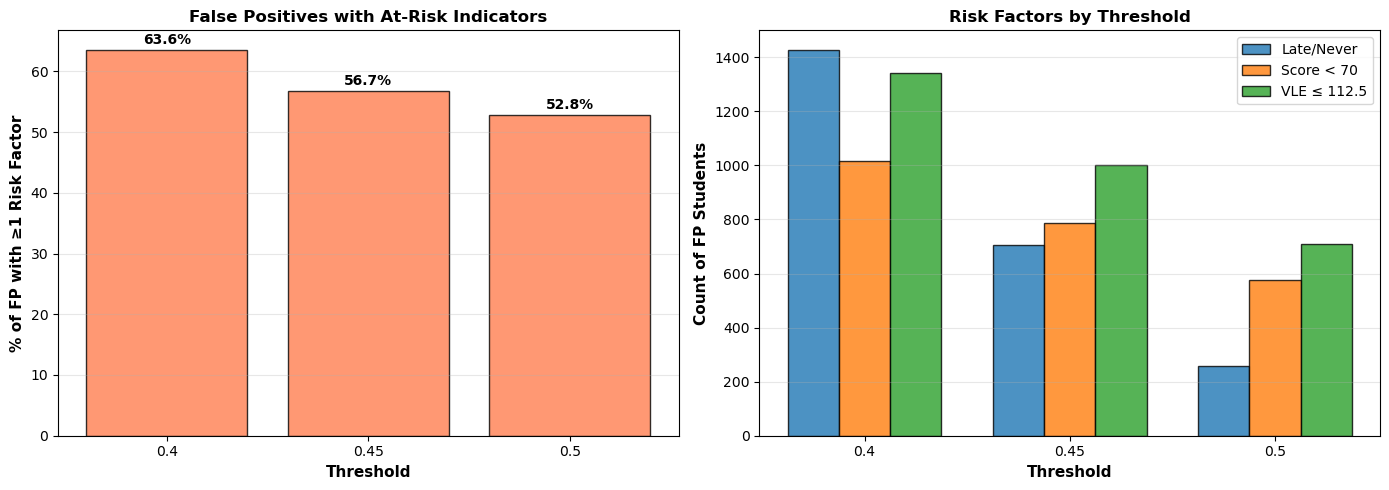


KEY INSIGHT
Most false positives (63.6% at threshold 0.4) show
at least one legitimate risk indicator, suggesting model may be
appropriately sensitive to early warning signs.


In [51]:
# FP Risk Factor Analysis: At-risk indicators at multiple thresholds
y_train_numeric = y_train.apply(lambda x: int(x[0]))
thresholds = [0.40, 0.45, 0.50]

print("=" * 90)
print("FALSE POSITIVE STUDENTS WITH AT-RISK INDICATORS")
print("=" * 90)

results = []

for threshold in thresholds:
    y_proba = final_lr_model.predict_proba(X_train)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)
    
    fp_mask = (y_pred == 1) & (y_train_numeric == 0)
    fp_students = X_train[fp_mask].copy()
    fp_students['score'] = df.loc[fp_students.index, 'score']
    
    # Check each risk factor
    has_late_never = fp_students['submission_type'].isin(['Late', 'Never'])
    has_low_score = fp_students['score'] < 70
    has_low_vle = fp_students['total_vle_pre_w3'] <= 112.5
    
    # At least one risk factor
    has_any_risk = has_late_never | has_low_score | has_low_vle
    
    n_fp = len(fp_students)
    n_with_risk = has_any_risk.sum()
    pct_with_risk = (n_with_risk / n_fp * 100) if n_fp > 0 else 0
    
    results.append({
        'Threshold': threshold,
        'Total FP': n_fp,
        'FP with Risk': n_with_risk,
        'Percentage': pct_with_risk,
        'Late/Never': has_late_never.sum(),
        'Score < 70': has_low_score.sum(),
        'VLE ≤ 112.5': has_low_vle.sum()
    })
    
    print(f"\nThreshold = {threshold:.2f}")
    print(f"  Total False Positives: {n_fp}")
    print(f"  FP with ≥1 risk factor: {n_with_risk} ({pct_with_risk:.1f}%)")
    print(f"    • Late/Never submission: {has_late_never.sum()} ({has_late_never.sum()/n_fp*100:.1f}%)")
    print(f"    • Score < 70: {has_low_score.sum()} ({has_low_score.sum()/n_fp*100:.1f}%)")
    print(f"    • VLE interactions ≤ 112.5: {has_low_vle.sum()} ({has_low_vle.sum()/n_fp*100:.1f}%)")

# Visualization
results_df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Percentage with risk factors
axes[0].bar(results_df['Threshold'].astype(str), results_df['Percentage'], 
            color='coral', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Threshold', fontsize=11, fontweight='bold')
axes[0].set_ylabel('% of FP with ≥1 Risk Factor', fontsize=11, fontweight='bold')
axes[0].set_title('False Positives with At-Risk Indicators', fontsize=12, fontweight='bold')
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(results_df['Percentage']):
    axes[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')

# Right: Breakdown by risk factor
x = np.arange(len(results_df))
width = 0.25
axes[1].bar(x - width, results_df['Late/Never'], width, label='Late/Never', alpha=0.8, edgecolor='black')
axes[1].bar(x, results_df['Score < 70'], width, label='Score < 70', alpha=0.8, edgecolor='black')
axes[1].bar(x + width, results_df['VLE ≤ 112.5'], width, label='VLE ≤ 112.5', alpha=0.8, edgecolor='black')
axes[1].set_xlabel('Threshold', fontsize=11, fontweight='bold')
axes[1].set_ylabel('Count of FP Students', fontsize=11, fontweight='bold')
axes[1].set_title('Risk Factors by Threshold', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(results_df['Threshold'].astype(str))
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n" + "=" * 90)
print("KEY INSIGHT")
print("=" * 90)
print(f"Most false positives ({results_df.iloc[0]['Percentage']:.1f}% at threshold 0.4) show")
print("at least one legitimate risk indicator, suggesting model may be")
print("appropriately sensitive to early warning signs.")

VLE ENGAGEMENT COMPARISON: True Positives vs All Passing Students

total_vle_pre_w3:
  True Positives (n=2856):  Mean = 145.64, Median = 112.50
  Passing (n=6220):        Mean = 367.52, Median = 240.00
  Difference (TP - Passing): -221.88
  Cohen's d: -0.720 (medium)
  p-value: 0.0000 ***

active_days_per_week_pre_w3:
  True Positives (n=2856):  Mean = 0.95, Median = 0.96
  Passing (n=6220):        Mean = 1.31, Median = 1.33
  Difference (TP - Passing): -0.36
  Cohen's d: -0.521 (medium)
  p-value: 0.0000 ***


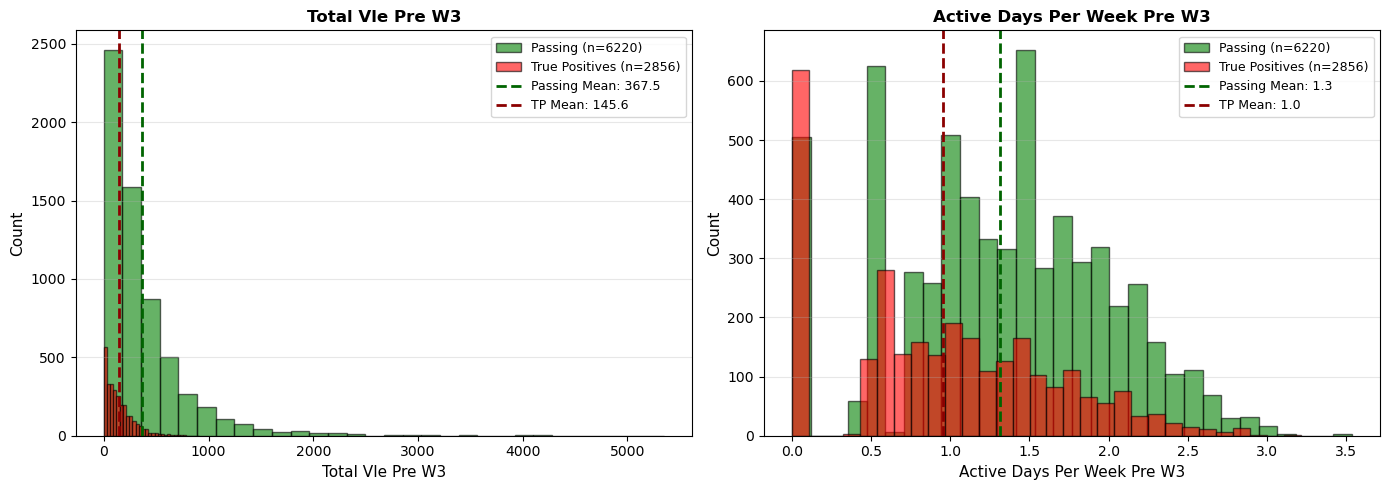


SUMMARY TABLE
                    Feature  TP Mean  Passing Mean  Difference  Cohen's d  p-value
           total_vle_pre_w3 145.6397      367.5244   -221.8847    -0.7199   0.0000
active_days_per_week_pre_w3   0.9530        1.3121     -0.3591    -0.5207   0.0000


In [50]:
# Compare VLE engagement: True Positives vs All Passing Students
from scipy import stats

y_train_numeric = y_train.apply(lambda x: int(x[0]))
y_pred = final_lr_model.predict(X_train)

# True Positives: predicted at-risk AND actually at-risk
tp_mask = (y_pred == 1) & (y_train_numeric == 1)
tp_students = X_train[tp_mask].copy()

# All Passing Students: actual outcome = 0 (Pass/Distinction)
passing_mask = (y_train_numeric == 0)
passing_students = X_train[passing_mask].copy()

print("=" * 90)
print("VLE ENGAGEMENT COMPARISON: True Positives vs All Passing Students")
print("=" * 90)

# Extract features
features = ['total_vle_pre_w3', 'active_days_per_week_pre_w3']

comparison_results = []

for feature in features:
    tp_vals = tp_students[feature].dropna()
    pass_vals = passing_students[feature].dropna()
    
    # Statistical test
    t_stat, p_val = stats.ttest_ind(tp_vals, pass_vals)
    pooled_std = np.sqrt((tp_vals.std()**2 + pass_vals.std()**2) / 2)
    cohens_d = (tp_vals.mean() - pass_vals.mean()) / pooled_std
    
    comparison_results.append({
        'Feature': feature,
        'TP Mean': tp_vals.mean(),
        'Passing Mean': pass_vals.mean(),
        'Difference': tp_vals.mean() - pass_vals.mean(),
        'Cohen\'s d': cohens_d,
        'p-value': p_val
    })
    
    print(f"\n{feature}:")
    print(f"  True Positives (n={len(tp_vals)}):  Mean = {tp_vals.mean():.2f}, Median = {tp_vals.median():.2f}")
    print(f"  Passing (n={len(pass_vals)}):        Mean = {pass_vals.mean():.2f}, Median = {pass_vals.median():.2f}")
    print(f"  Difference (TP - Passing): {tp_vals.mean() - pass_vals.mean():.2f}")
    print(f"  Cohen's d: {cohens_d:.3f} ({'large' if abs(cohens_d) > 0.8 else 'medium' if abs(cohens_d) > 0.5 else 'small'})")
    print(f"  p-value: {p_val:.4f} {'***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, feature in enumerate(features):
    tp_vals = tp_students[feature].dropna()
    pass_vals = passing_students[feature].dropna()
    
    axes[idx].hist(pass_vals, bins=30, alpha=0.6, label=f'Passing (n={len(pass_vals)})', 
                   color='green', edgecolor='black')
    axes[idx].hist(tp_vals, bins=30, alpha=0.6, label=f'True Positives (n={len(tp_vals)})', 
                   color='red', edgecolor='black')
    axes[idx].axvline(pass_vals.mean(), color='darkgreen', linestyle='--', linewidth=2, label=f'Passing Mean: {pass_vals.mean():.1f}')
    axes[idx].axvline(tp_vals.mean(), color='darkred', linestyle='--', linewidth=2, label=f'TP Mean: {tp_vals.mean():.1f}')
    
    axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
    axes[idx].set_ylabel('Count', fontsize=11)
    axes[idx].set_title(f'{feature.replace("_", " ").title()}', fontweight='bold', fontsize=12)
    axes[idx].legend(fontsize=9)
    axes[idx].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
results_df = pd.DataFrame(comparison_results)
print("\n" + "=" * 90)
print("SUMMARY TABLE")
print("=" * 90)
print(results_df.to_string(index=False, float_format=lambda x: f'{x:.4f}'))